In [1]:
import pandas as pd

In [2]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [3]:
# import the PCC data
pcc_4S = pd.read_csv("pcc_4S.csv", index_col=0)
pcc_I = pd.read_csv("pcc_I.csv", index_col=0)
pcc_III = pd.read_csv("pcc_III.csv", index_col=0)
pcc_IV = pd.read_csv("pcc_IV.csv", index_col=0)
# pcc_NA = pd.read_csv("pcc_NA.csv", index_col=0)
pcc_4S

,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.101876,-0.105444,0.294110,0.285490,0.043094,0.273760,0.154205,0.535308,0.574785,...,-0.214314,-0.225862,0.491546,0.099288,0.247549,-0.177206,0.227948,-0.268659,0.047149,-0.721479
DPM1,0.101876,1.000000,0.040753,0.366840,0.112091,-0.203120,0.277659,0.230100,0.012097,-0.223822,...,-0.017635,-0.288416,0.410572,0.095112,0.348526,0.411757,-0.319794,-0.130364,0.225836,-0.290486
SCYL3,-0.105444,0.040753,1.000000,0.378629,-0.077102,0.299282,0.164965,0.239981,-0.208912,0.051952,...,0.622151,0.586767,0.021289,0.030100,0.392734,0.130584,0.244455,0.441587,0.019297,0.122590
C1orf112,0.294110,0.366840,0.378629,1.000000,0.090887,0.202204,0.276277,0.408218,-0.028448,0.043607,...,0.243748,0.095764,0.304032,0.119730,0.447024,-0.121551,0.210028,0.290213,-0.177887,-0.509990
FGR,0.285490,0.112091,-0.077102,0.090887,1.000000,-0.117195,0.082018,-0.002028,0.309746,0.378912,...,0.061240,0.080967,0.612712,0.711971,0.284195,0.071398,0.207367,-0.222435,0.442745,-0.239477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,-0.177206,0.411757,0.130584,-0.121551,0.071398,-0.431935,-0.214156,-0.163260,0.100622,-0.076020,...,0.350383,0.075384,0.190224,0.019012,0.208961,1.000000,-0.613841,-0.308633,0.599359,0.277204
CYB561D2,0.227948,-0.319794,0.244455,0.210028,0.207367,0.558621,0.306613,0.189181,0.124066,0.351359,...,0.070697,0.309529,0.159834,0.172155,0.138332,-0.613841,1.000000,0.342137,-0.458748,-0.186283
CCDC7,-0.268659,-0.130364,0.441587,0.290213,-0.222435,0.542627,0.210271,0.254534,-0.347429,-0.078083,...,0.285602,0.507611,-0.117943,-0.003734,0.117266,-0.308633,0.342137,1.000000,-0.371967,0.101145


In [4]:
# Set the name of the DataFrame
pcc_4S.name = "pcc_4S"
pcc_I.name = "pcc_I"
pcc_III.name = "pcc_III"
pcc_IV.name = "pcc_IV"
# pcc_NA.name = "pcc_NA"

construct a weighted graph as leiden's input from the 50-PC distance space. Using Euclidean distance in the space, selecting top k% shortest distance as edges, normalize the distance to between 0-1, and then take the reciprocal to make smaller distances larger weights and vice versa

In [5]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from SWITCH import PCC_SWITCH_pcc_to_module_binary, module_to_json

In [6]:
%pwd
%cd /home/jovyan/work/parameter_tuning/PCC_SWITCH/knd_binary/Cell/
%pwd

/home/jovyan/work/parameter_tuning/PCC_SWIM/knd_binary/Cell


'/home/jovyan/work/parameter_tuning/PCC_SWIM/knd_binary/Cell'

Cell: resolution = 0.6
Science: 

threshold_percentile = 10%: threshold_distance = 23.68169431941818
Number of connected components: 1


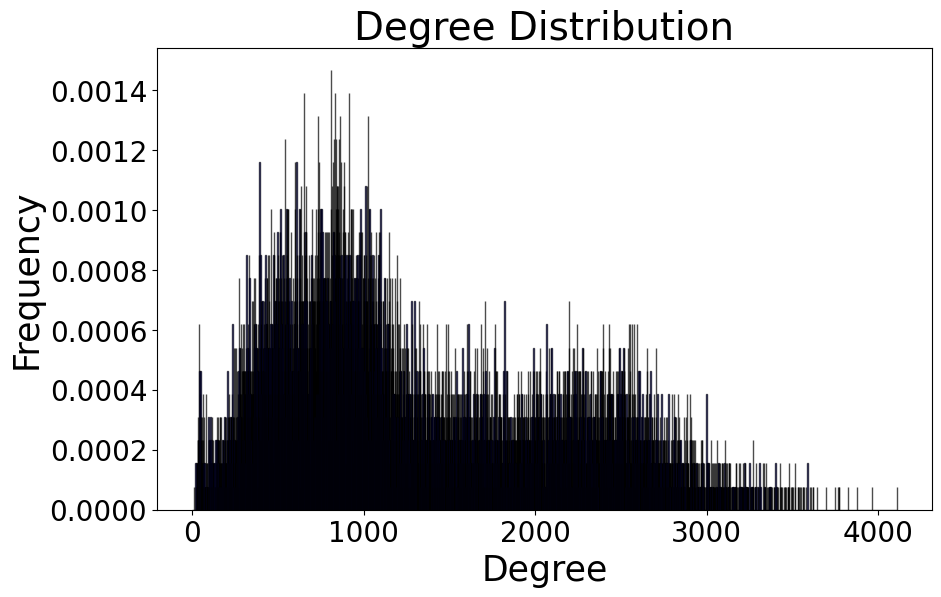

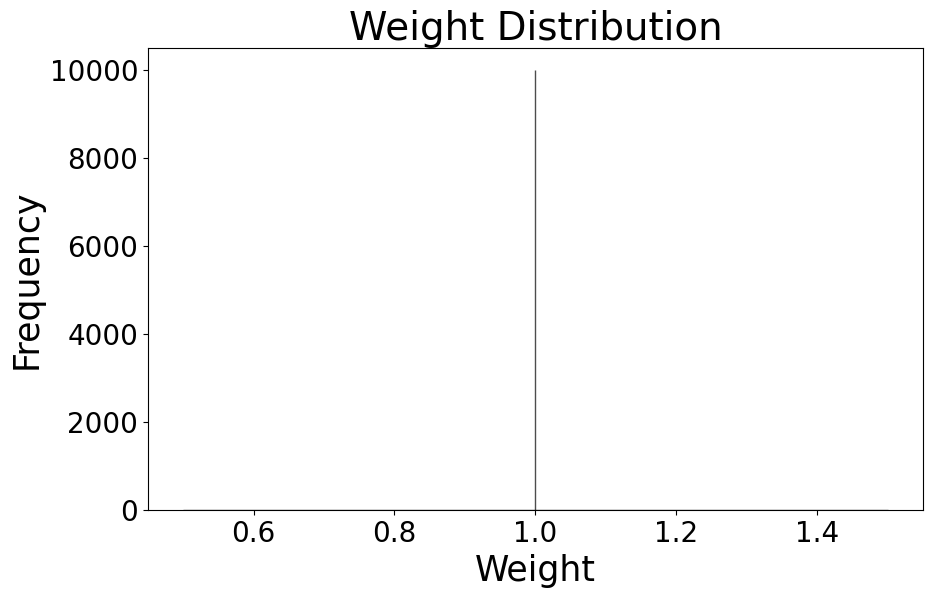

Number of clusters: 21
Number of modules: 18
threshold_percentile = 10%: threshold_distance = 23.68169431941818
Number of connected components: 1


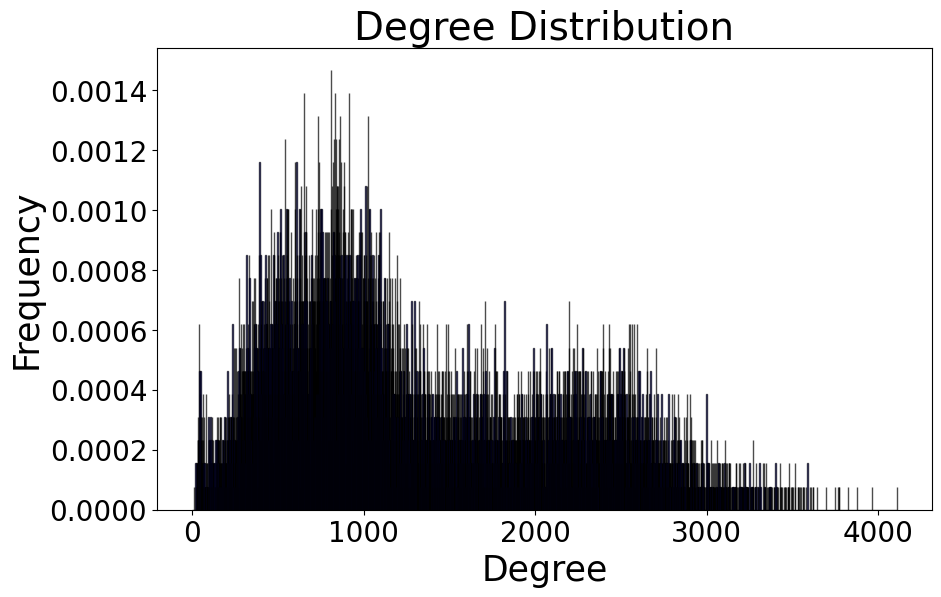

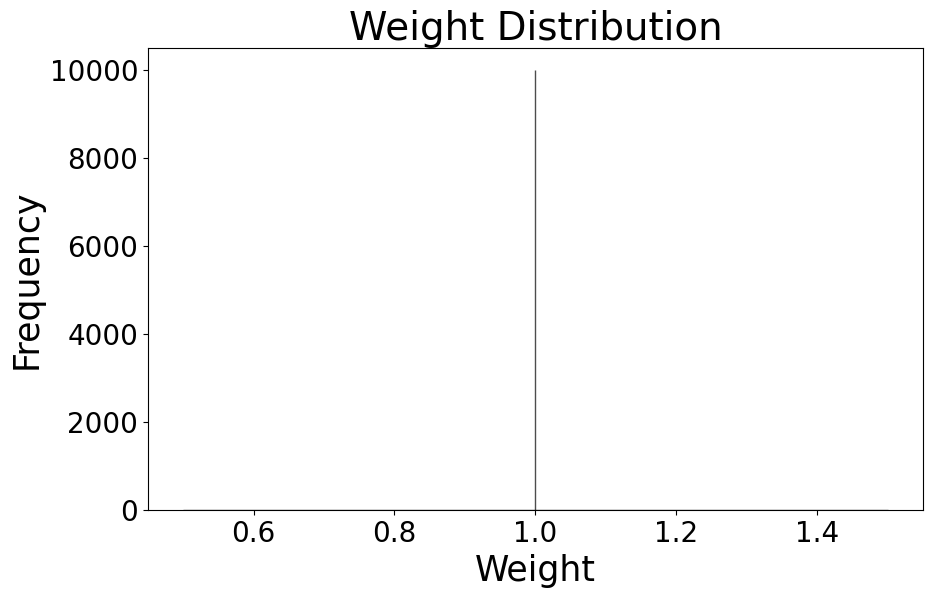

IOStream.flush timed out
IOStream.flush timed out


Number of clusters: 44
Number of modules: 32
threshold_percentile = 10%: threshold_distance = 23.68169431941818
Number of connected components: 1


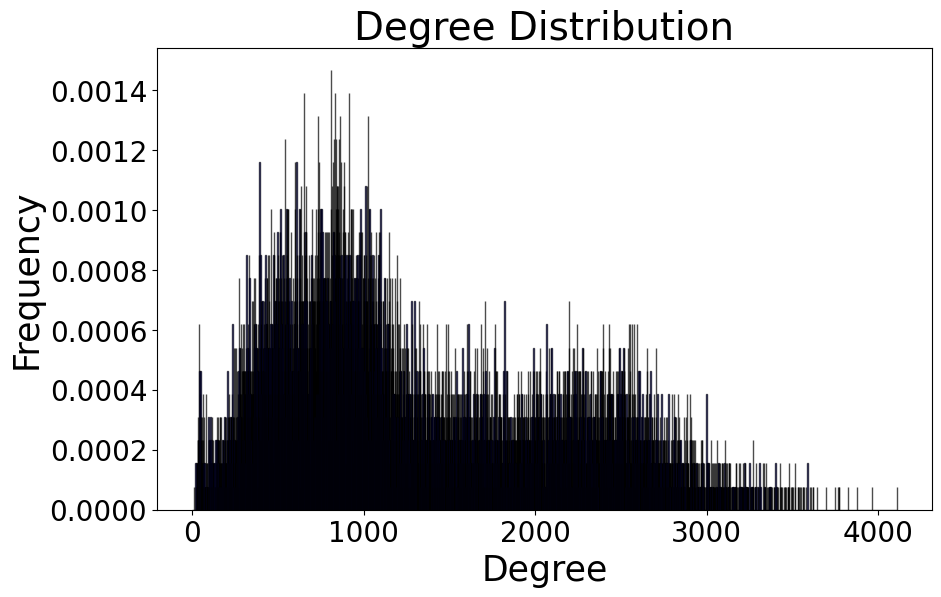

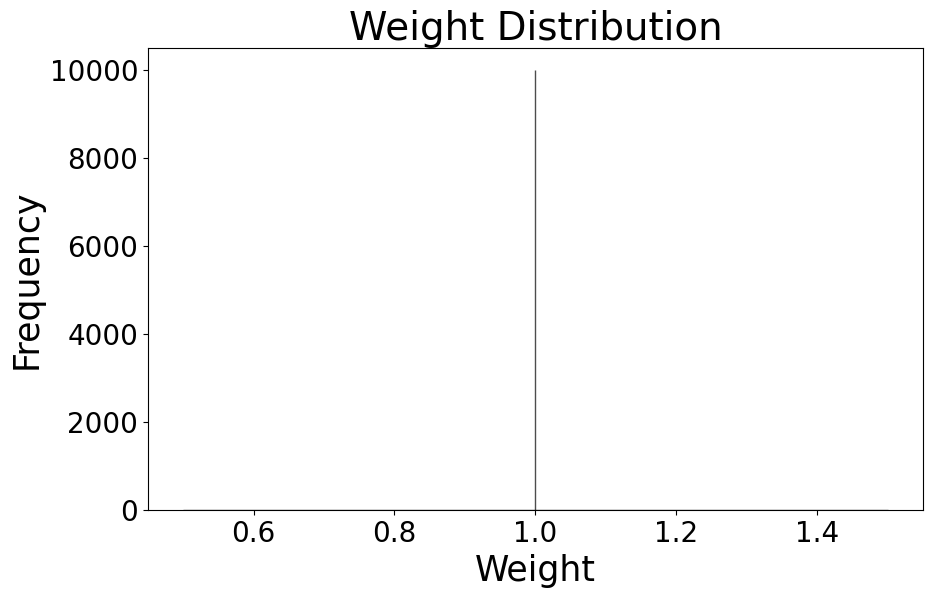

Number of clusters: 59
Number of modules: 47
threshold_percentile = 10%: threshold_distance = 23.68169431941818
Number of connected components: 1


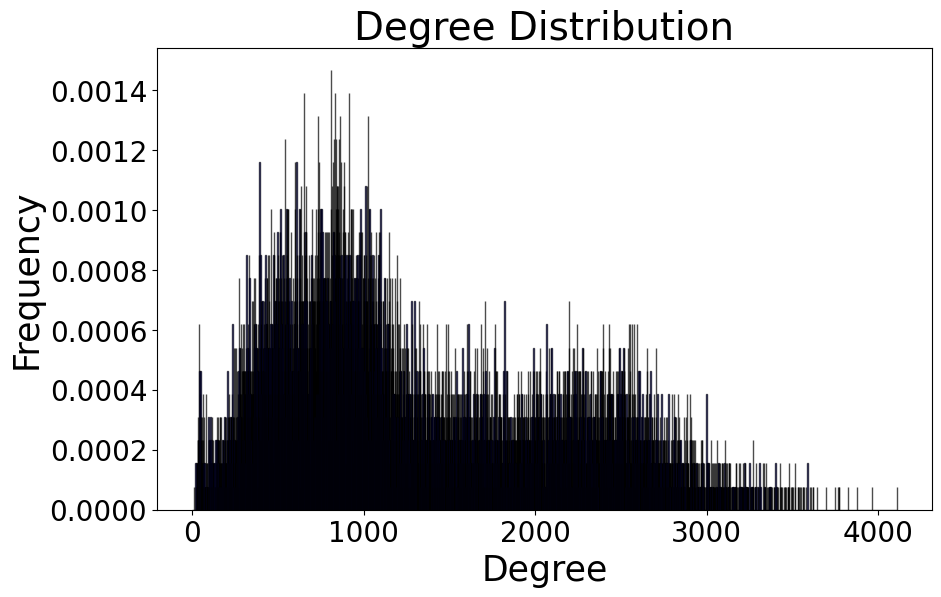

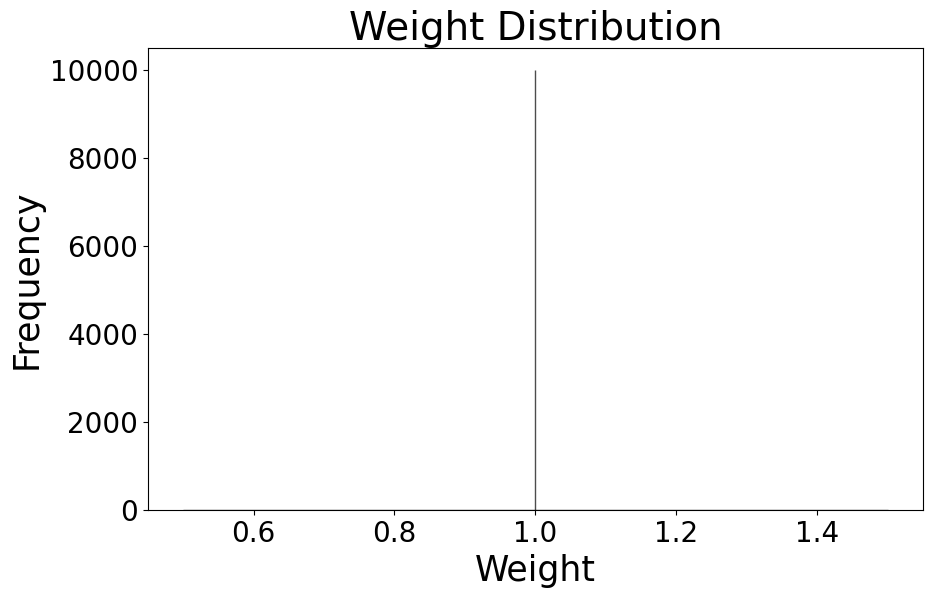

Number of clusters: 90
Number of modules: 71
threshold_percentile = 10%: threshold_distance = 23.68169431941818
Number of connected components: 1


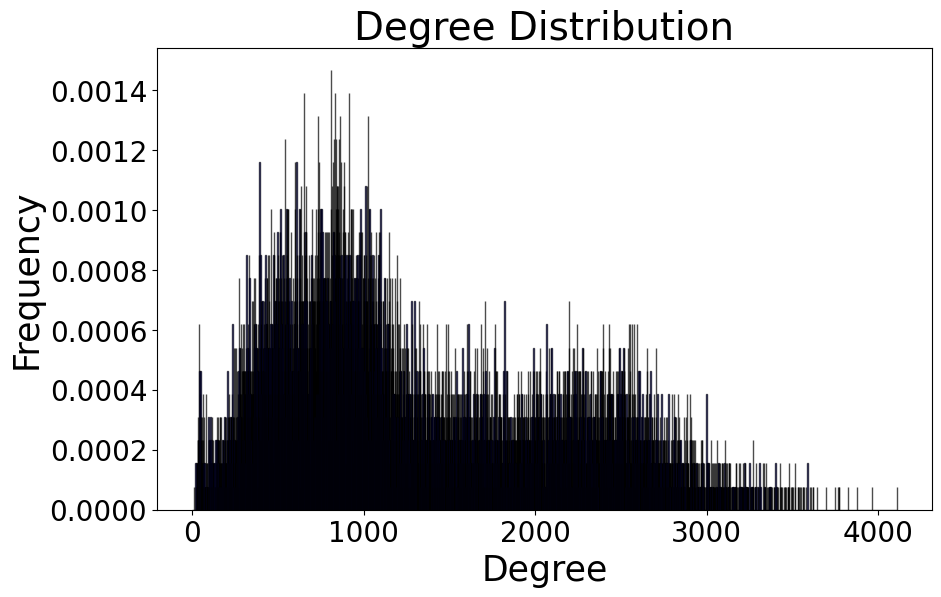

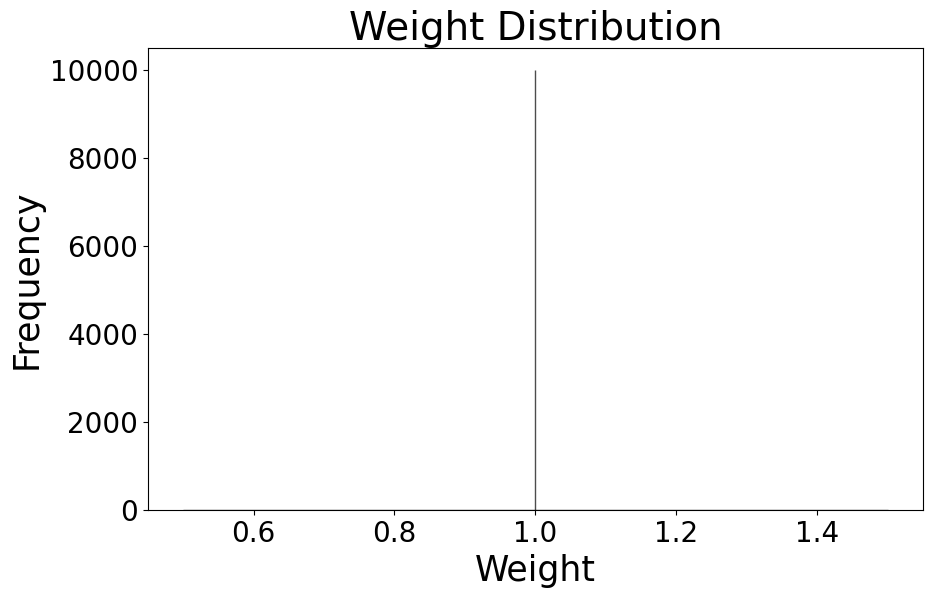

Number of clusters: 122
Number of modules: 98
threshold_percentile = 10%: threshold_distance = 23.68169431941818
Number of connected components: 1


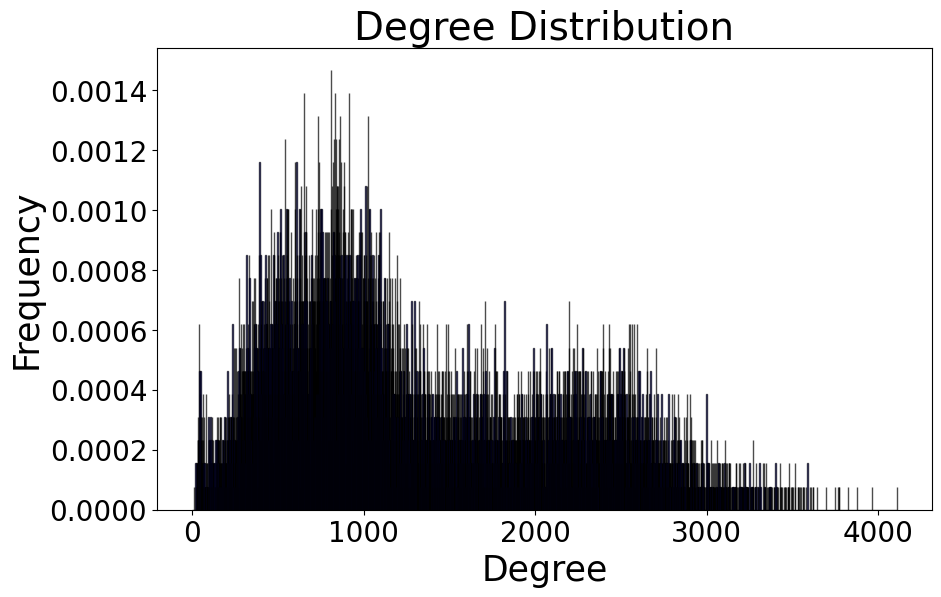

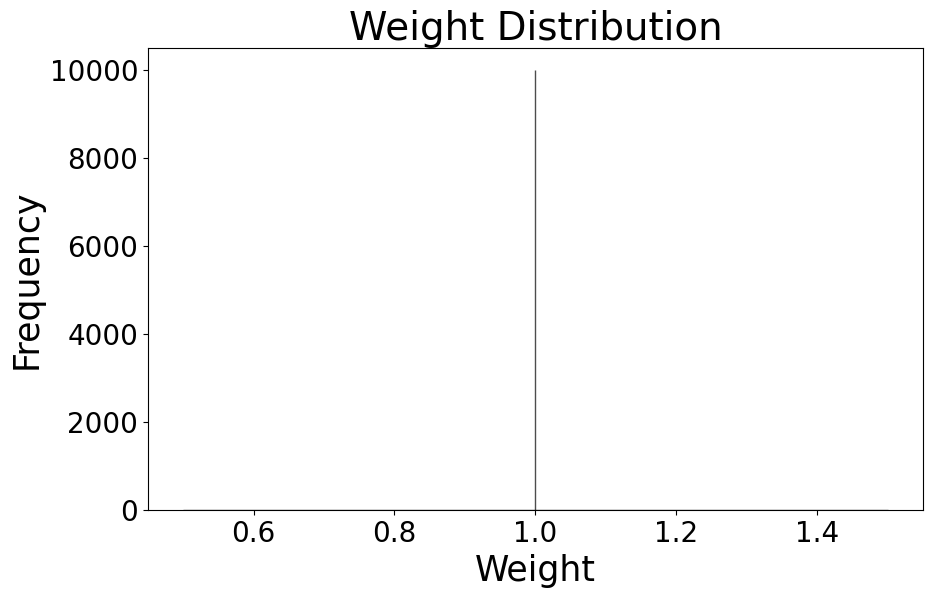

Number of clusters: 157
Number of modules: 132
threshold_percentile = 10%: threshold_distance = 23.68169431941818
Number of connected components: 1


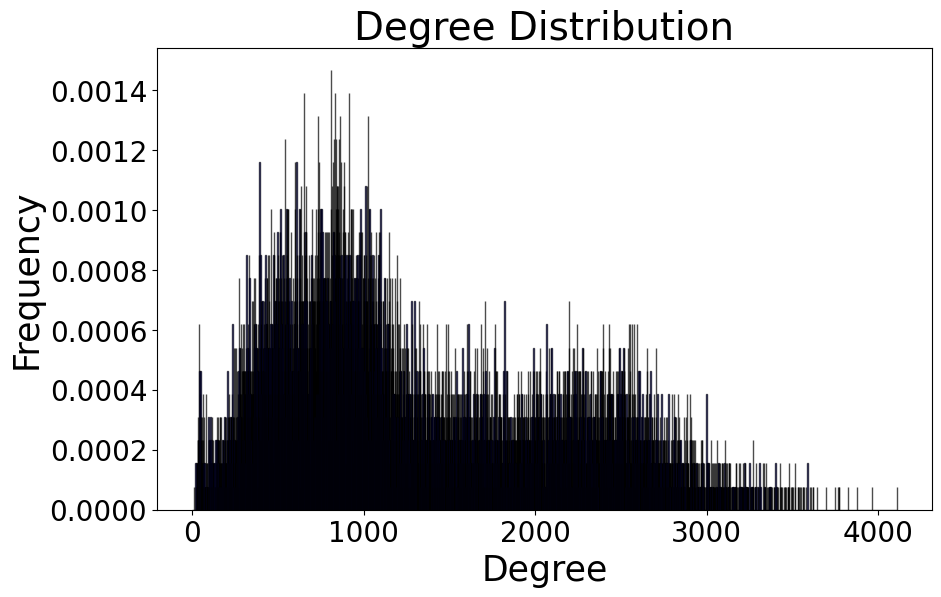

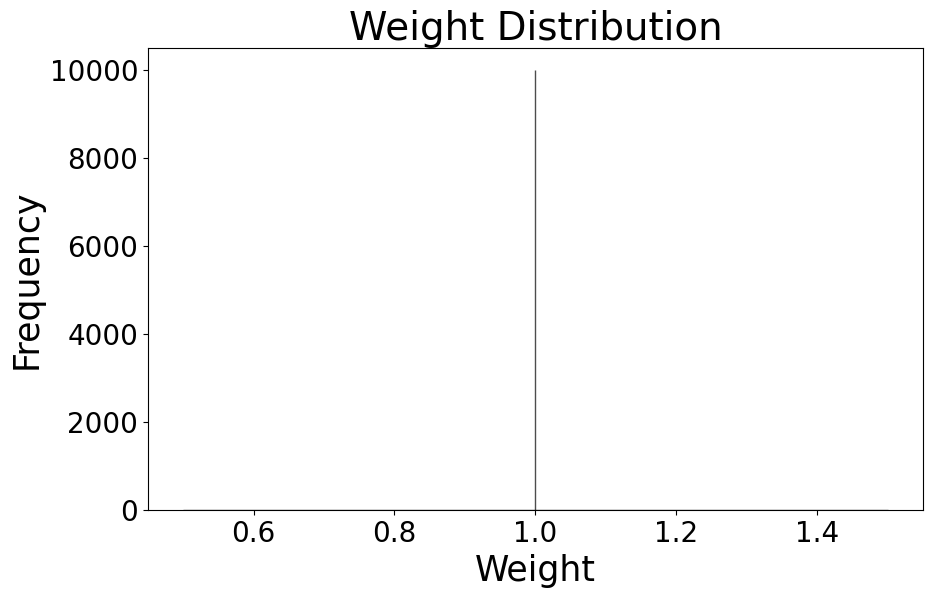

Number of clusters: 193
Number of modules: 170
threshold_percentile = 10%: threshold_distance = 23.68169431941818
Number of connected components: 1


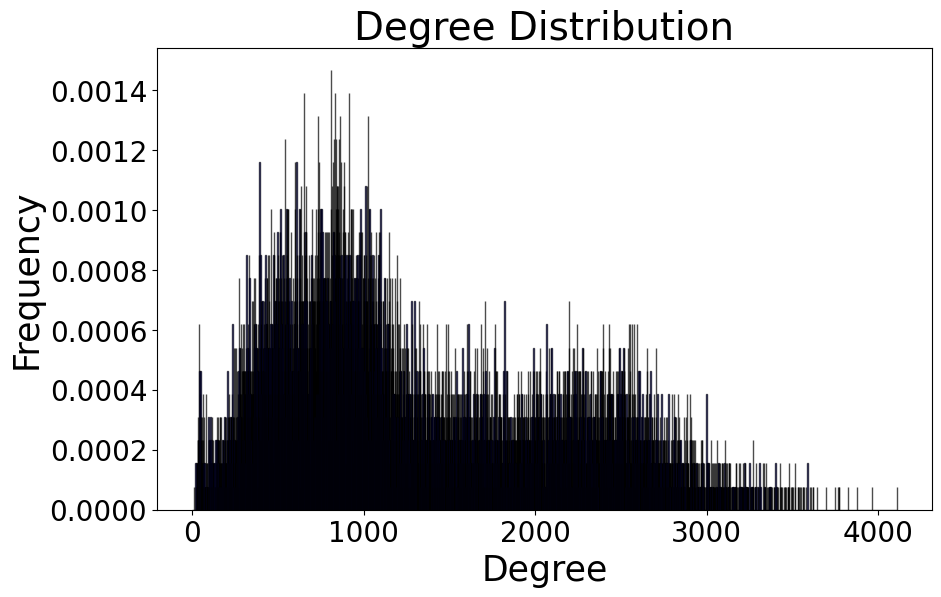

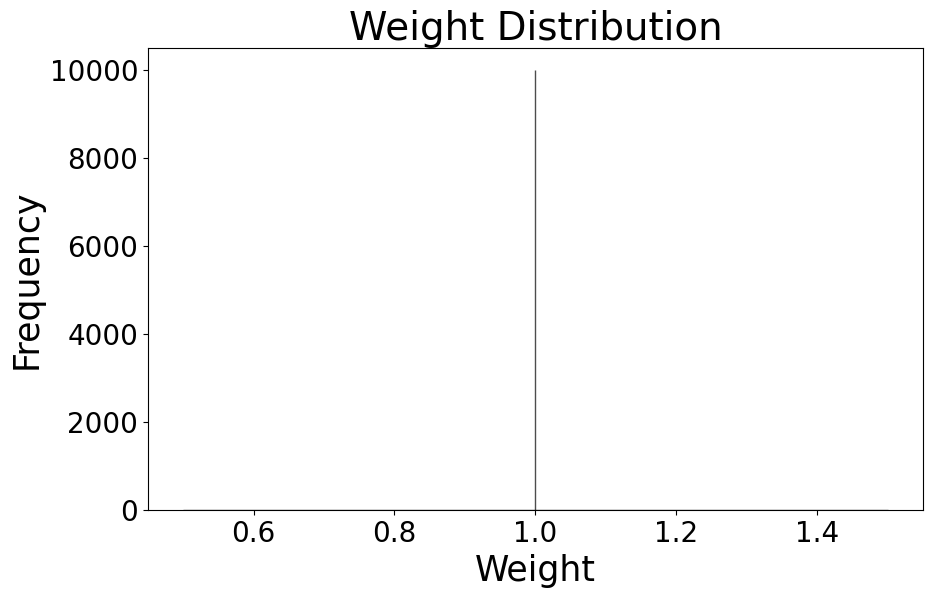

Number of clusters: 264
Number of modules: 218
threshold_percentile = 10%: threshold_distance = 23.68169431941818
Number of connected components: 1


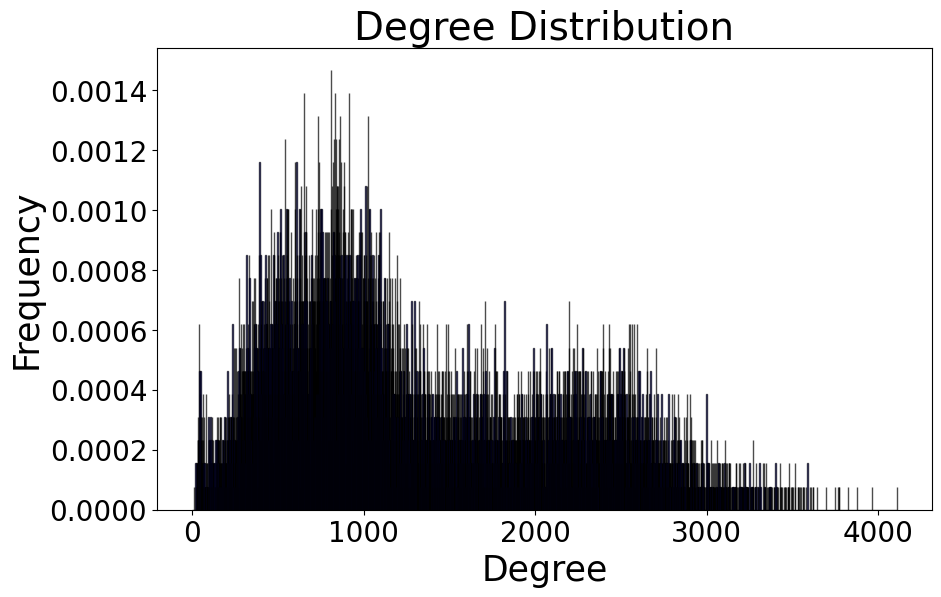

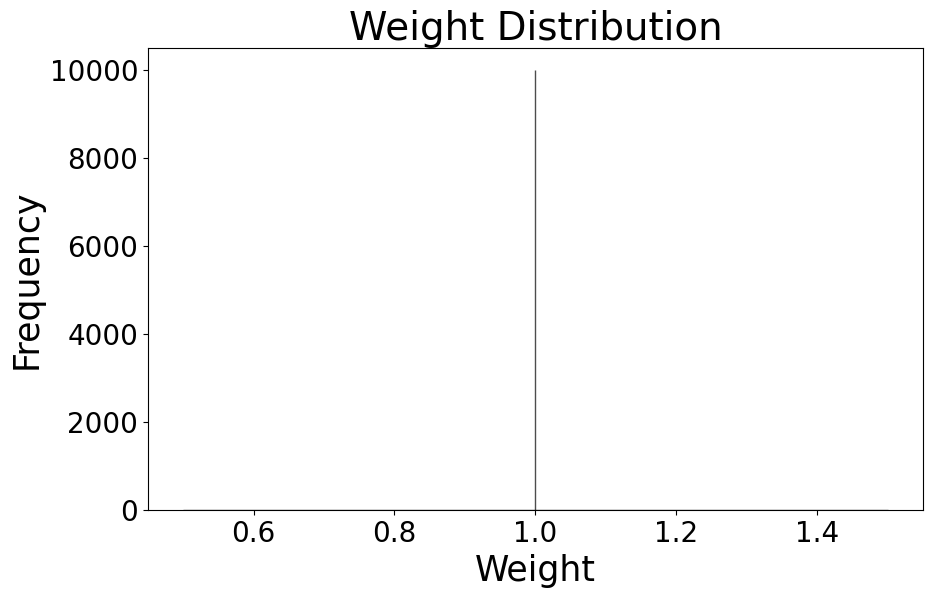

Number of clusters: 342
Number of modules: 281


In [8]:
resolution_values = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]  # for 10%: 20~280 modules
for resolution_parameter in resolution_values:
    module_4S = PCC_SWITCH_pcc_to_module_binary(pcc_coordinate=pcc_4S, fig_path1=f"./figures/degree_distribution_4S_{resolution_parameter}.svg", fig_path2=f"./figures/weight_distribution_4S_{resolution_parameter}.svg", threshold_percentile=10, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_4S, file_path=f"module_4S_{resolution_parameter}.json")

threshold_percentile = 10%: threshold_distance = 25.83294853726361
Number of connected components: 1


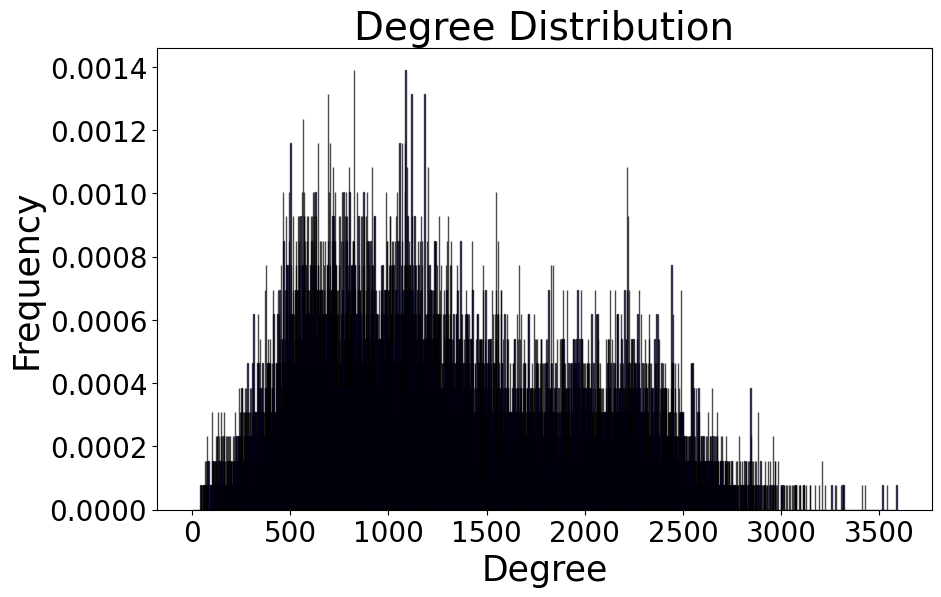

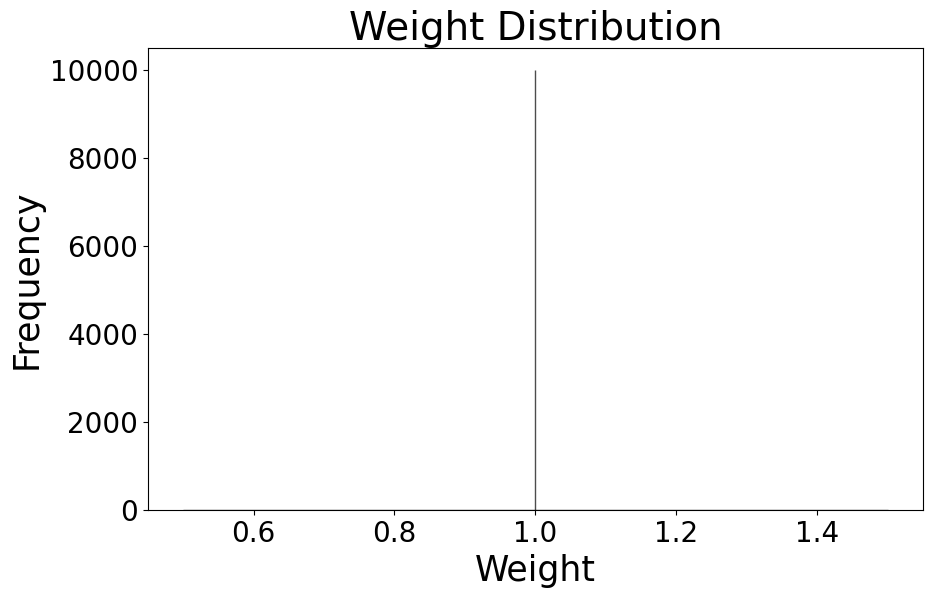

Number of clusters: 17
Number of modules: 13
threshold_percentile = 10%: threshold_distance = 25.83294853726361
Number of connected components: 1


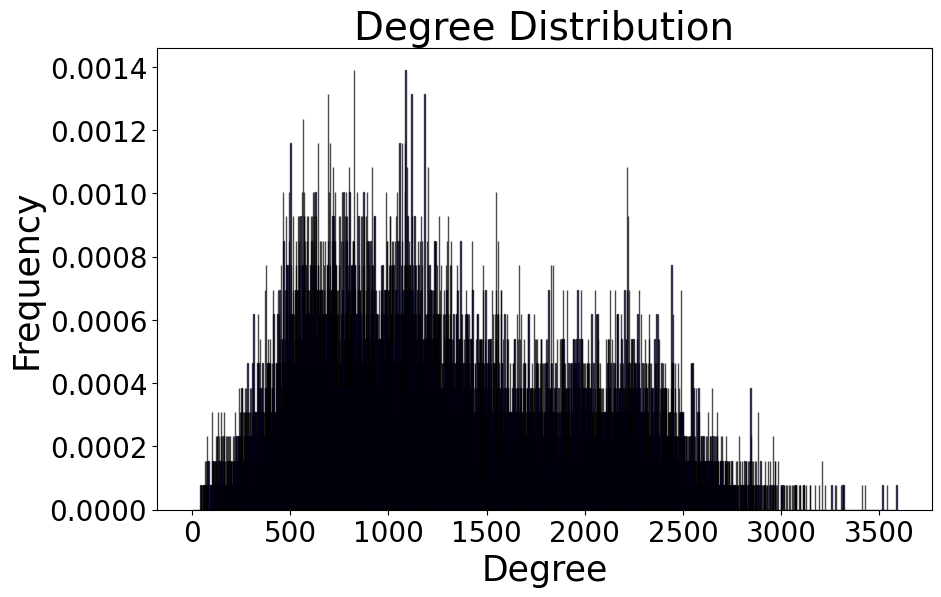

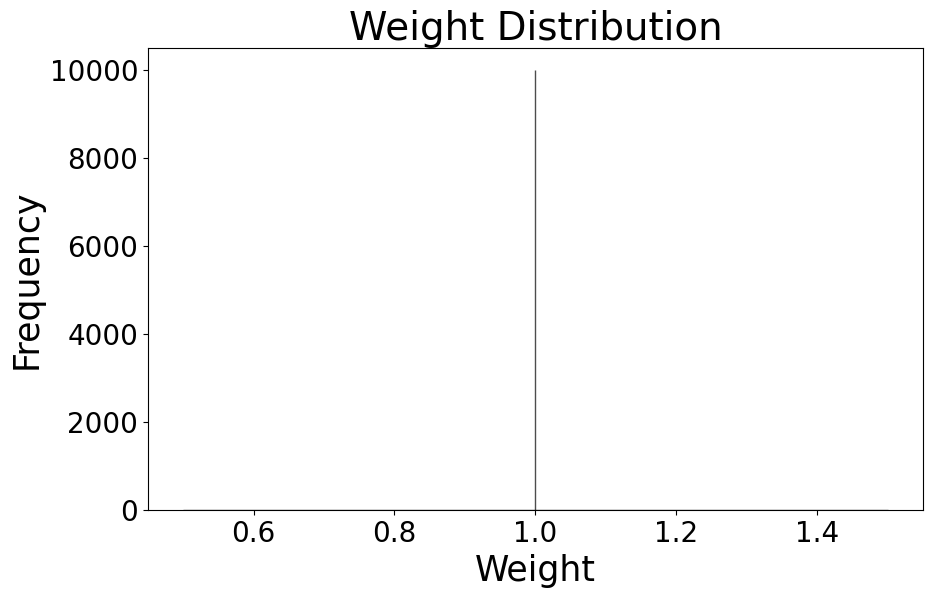

Number of clusters: 34
Number of modules: 27
threshold_percentile = 10%: threshold_distance = 25.83294853726361
Number of connected components: 1


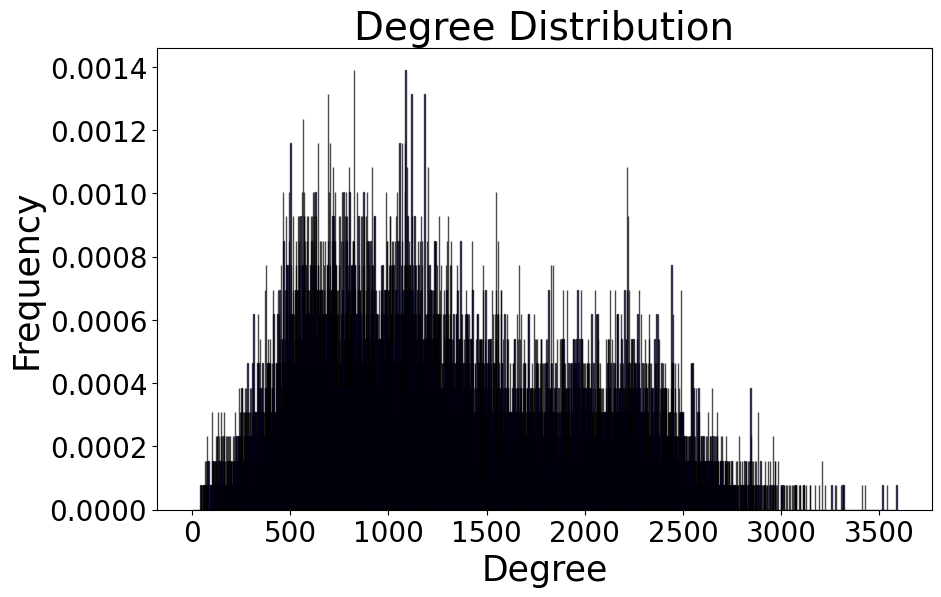

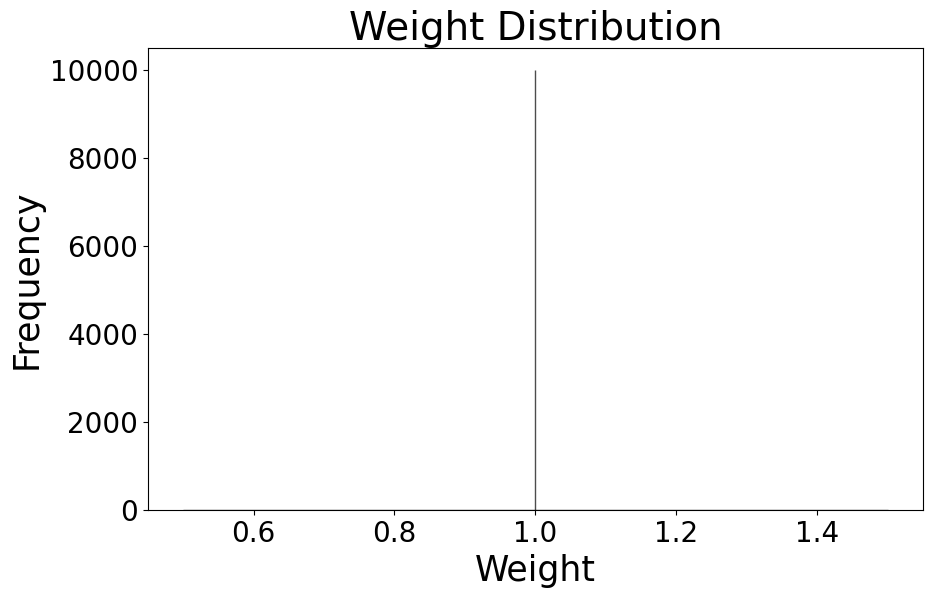

Number of clusters: 50
Number of modules: 41
threshold_percentile = 10%: threshold_distance = 25.83294853726361
Number of connected components: 1


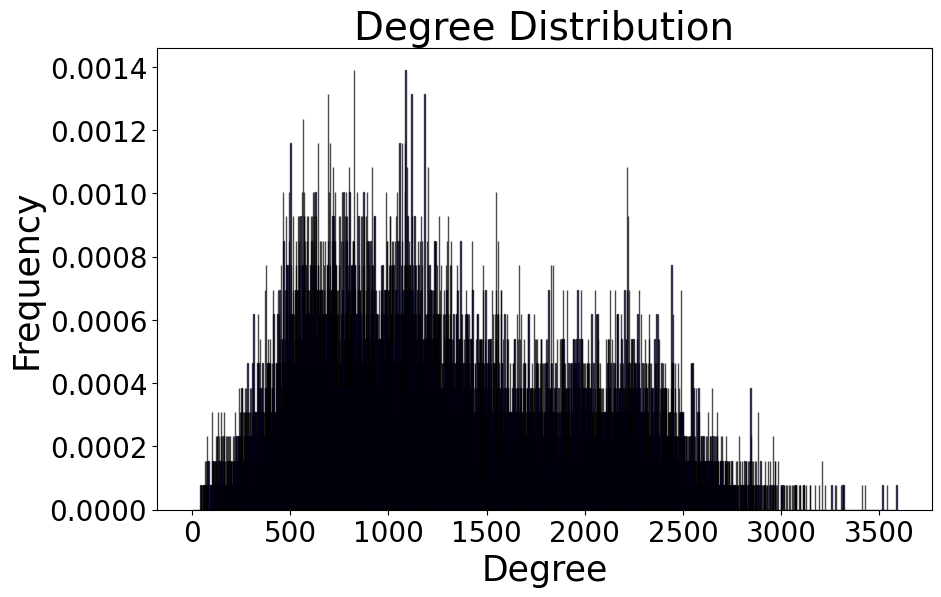

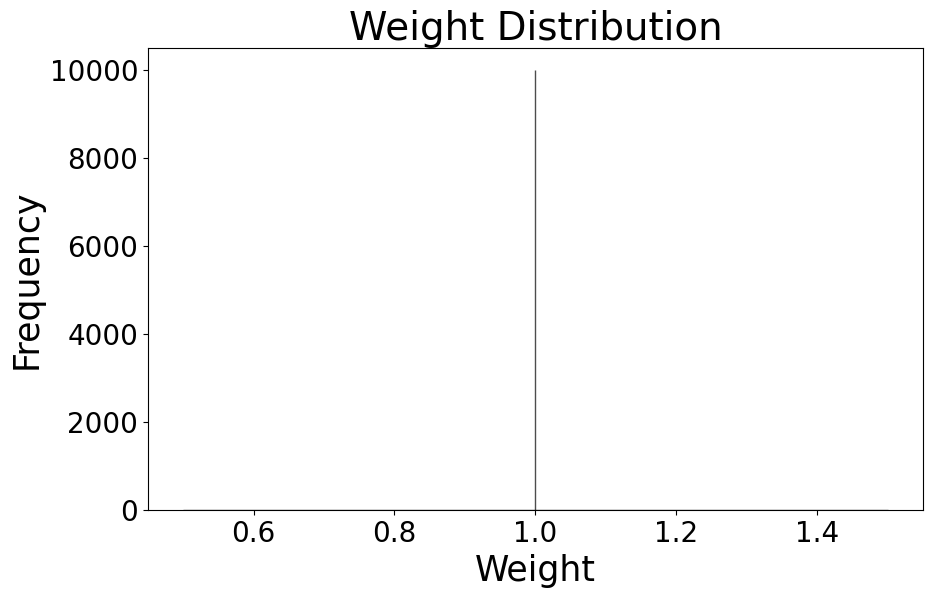

Number of clusters: 70
Number of modules: 61
threshold_percentile = 10%: threshold_distance = 25.83294853726361
Number of connected components: 1


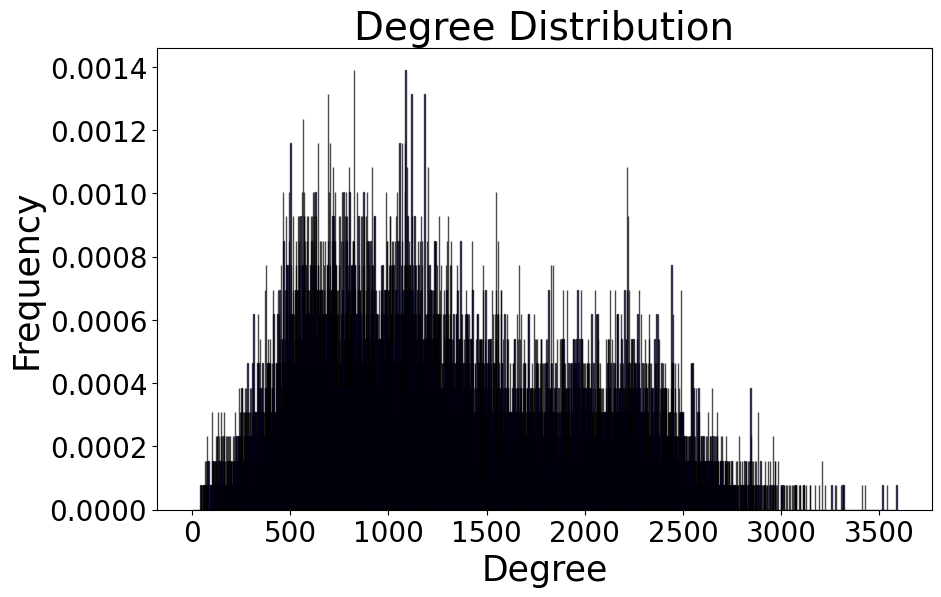

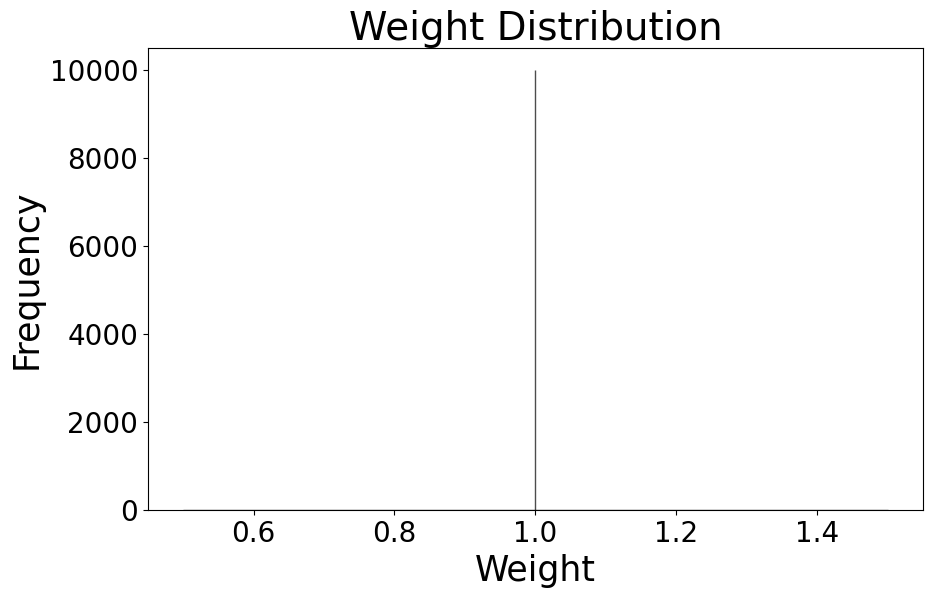

IOStream.flush timed out


Number of clusters: 102
Number of modules: 87
threshold_percentile = 10%: threshold_distance = 25.83294853726361
Number of connected components: 1


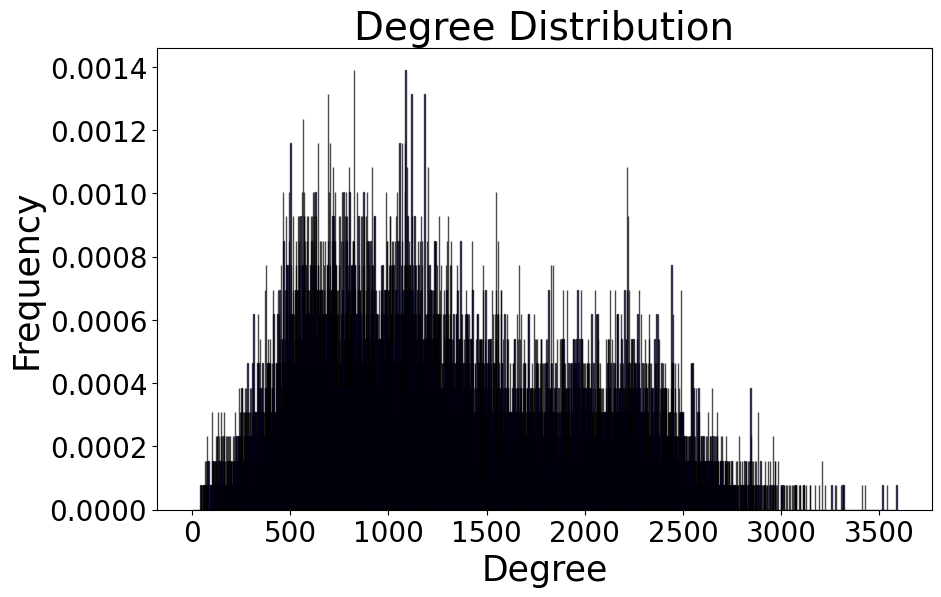

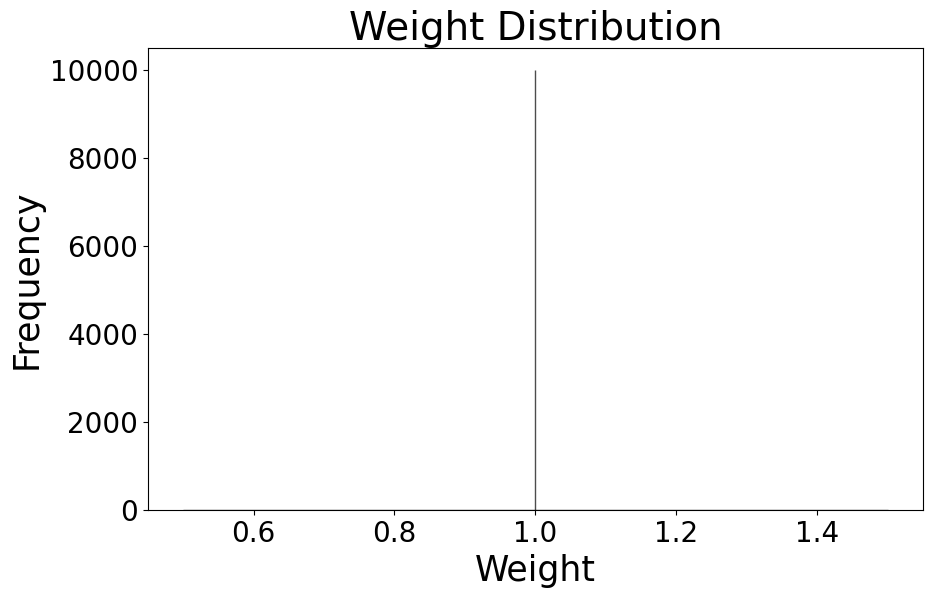

Number of clusters: 125
Number of modules: 111
threshold_percentile = 10%: threshold_distance = 25.83294853726361
Number of connected components: 1


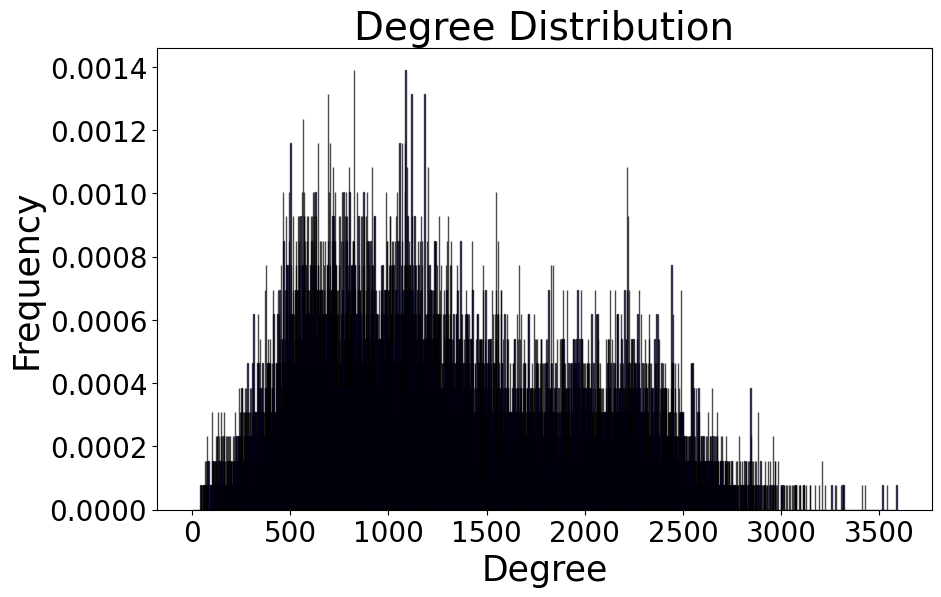

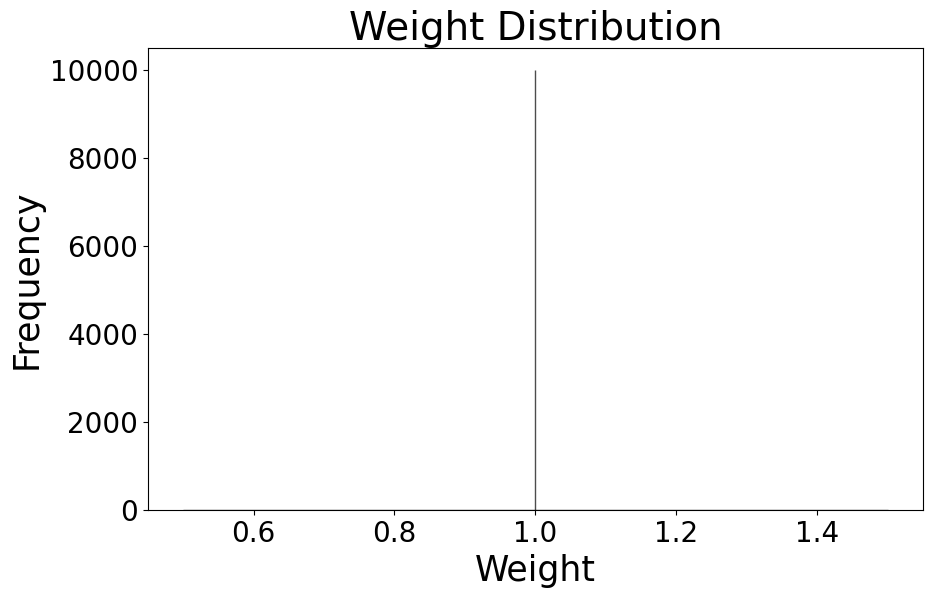

Number of clusters: 173
Number of modules: 143
threshold_percentile = 10%: threshold_distance = 25.83294853726361
Number of connected components: 1


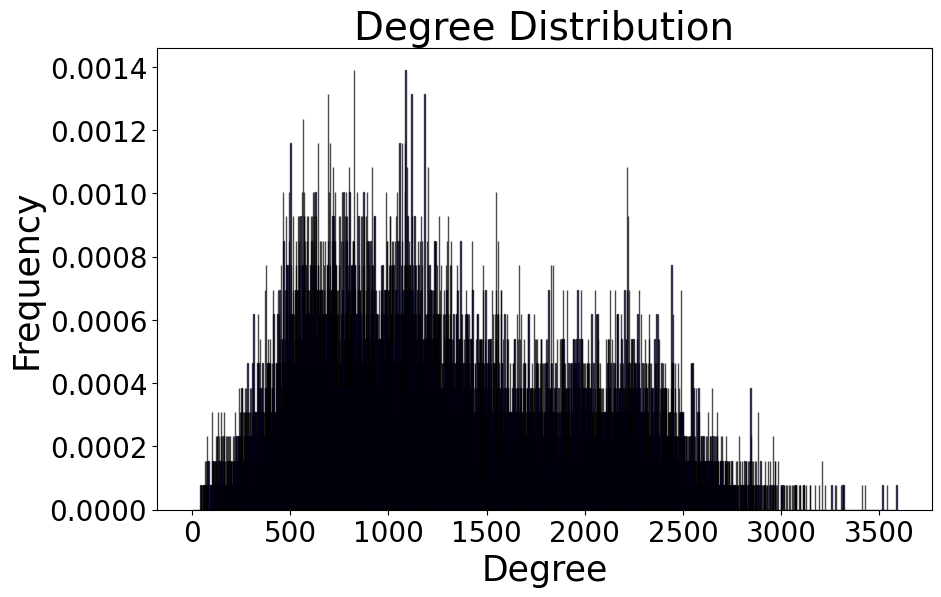

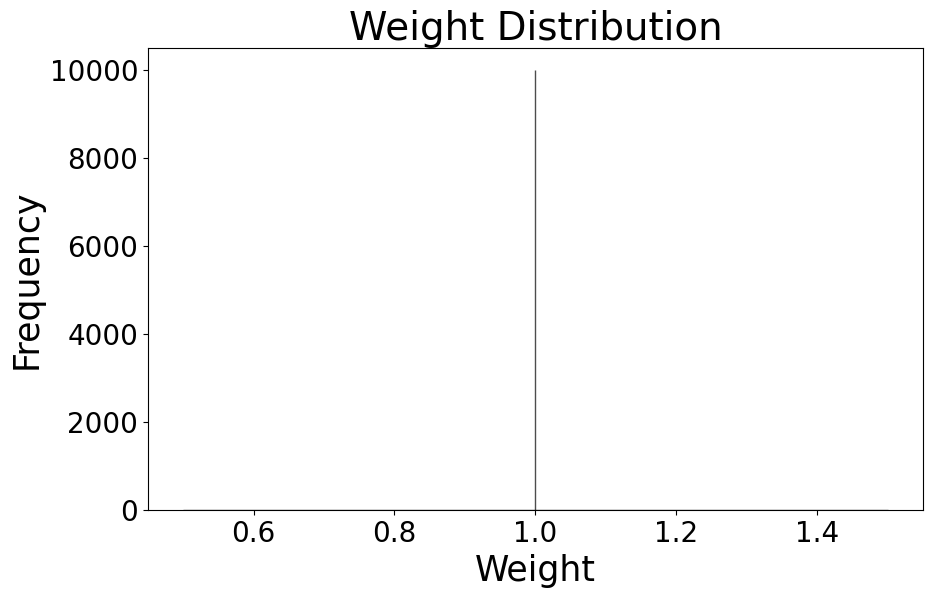

Number of clusters: 221
Number of modules: 189
threshold_percentile = 10%: threshold_distance = 25.83294853726361
Number of connected components: 1


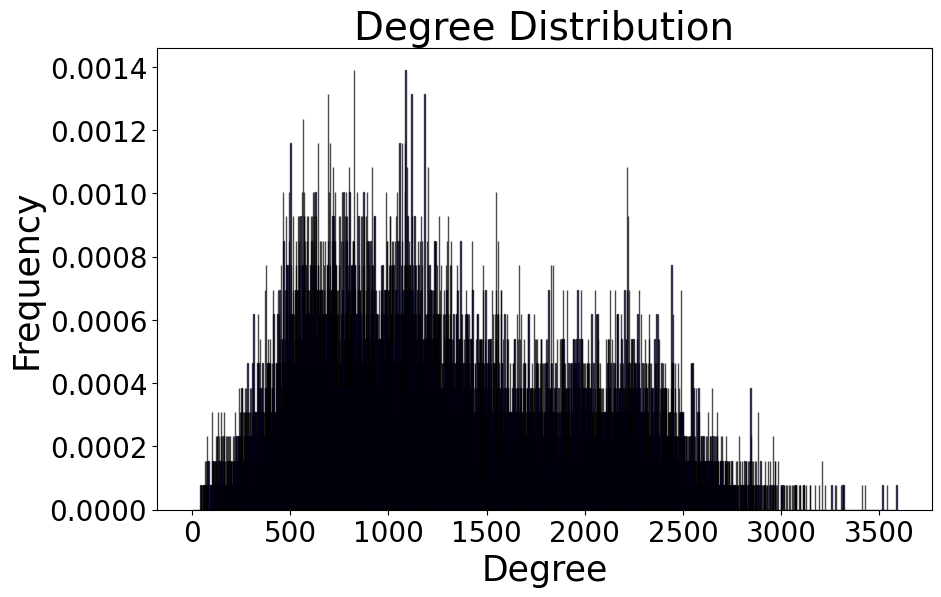

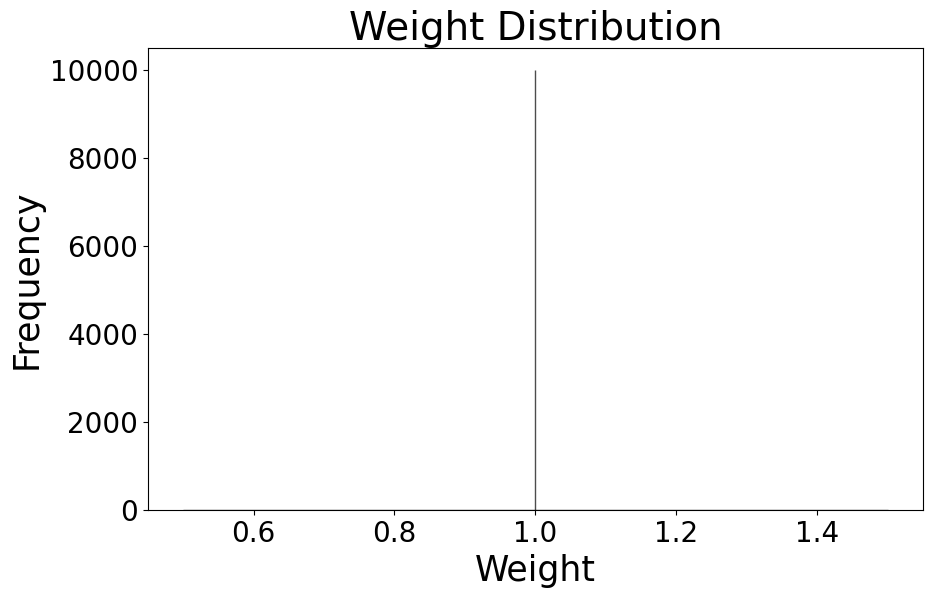

Number of clusters: 306
Number of modules: 266


In [9]:
for resolution_parameter in resolution_values:
    module_I = PCC_SWITCH_pcc_to_module_binary(pcc_coordinate=pcc_I, fig_path1=f"./figures/degree_distribution_I_{resolution_parameter}.svg", fig_path2=f"./figures/weight_distribution_I_{resolution_parameter}.svg", threshold_percentile=10, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_I, file_path=f"module_I_{resolution_parameter}.json")

threshold_percentile = 10%: threshold_distance = 25.355213034901496
Number of connected components: 1


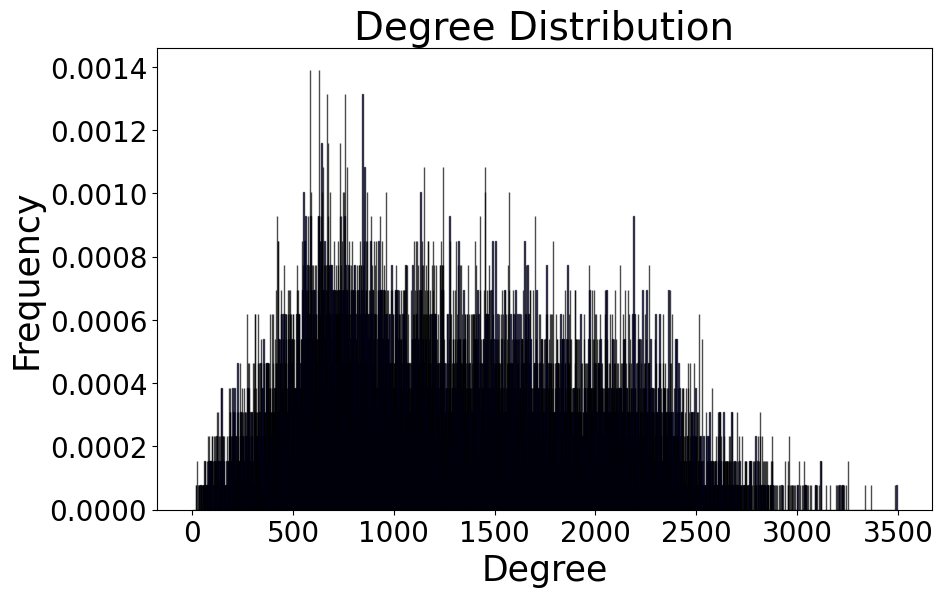

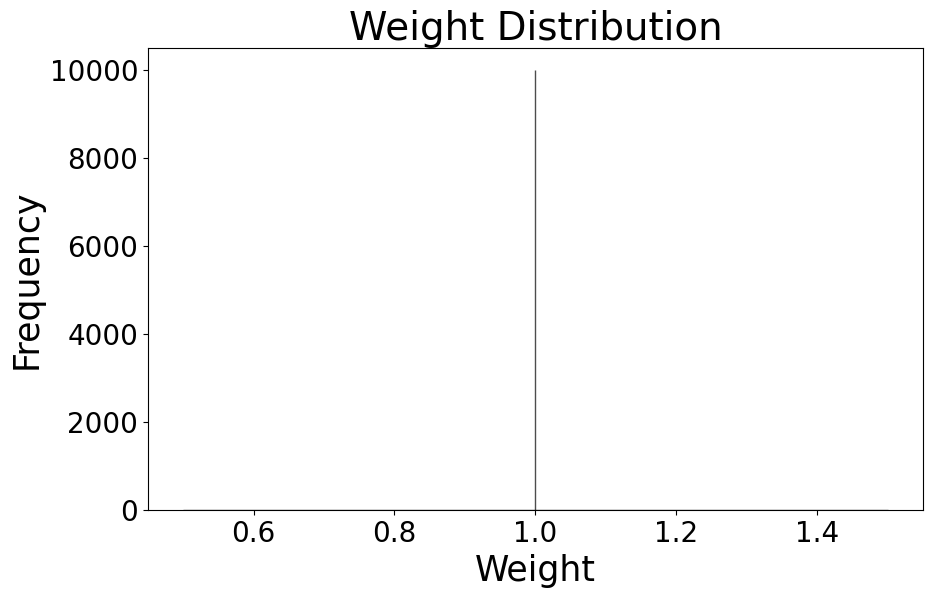

Number of clusters: 19
Number of modules: 13
threshold_percentile = 10%: threshold_distance = 25.355213034901496
Number of connected components: 1


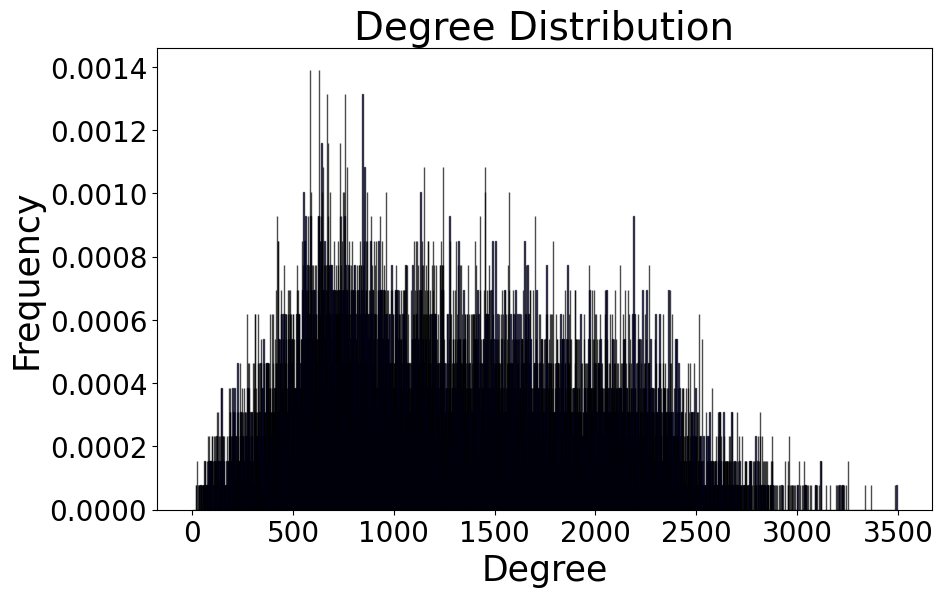

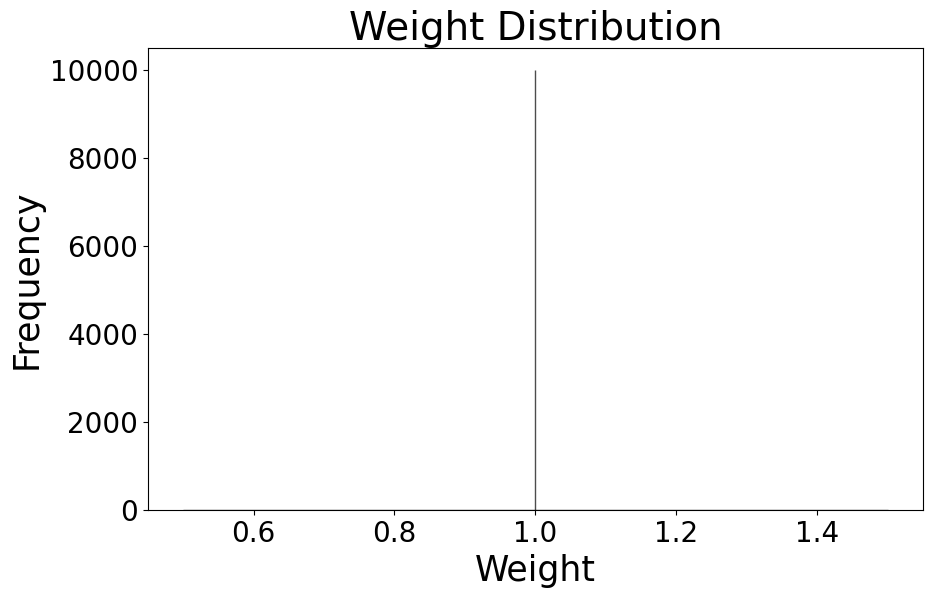

Number of clusters: 32
Number of modules: 29
threshold_percentile = 10%: threshold_distance = 25.355213034901496
Number of connected components: 1


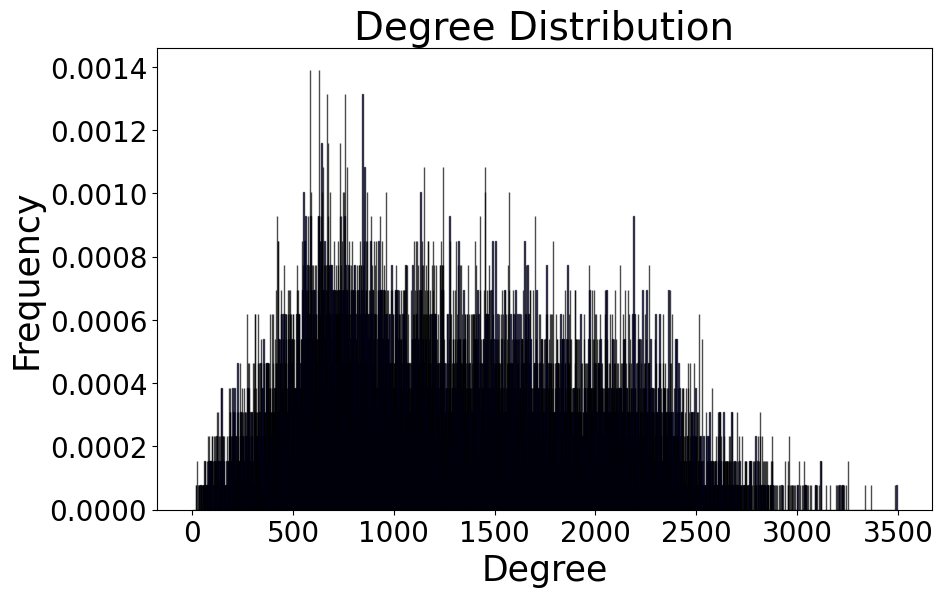

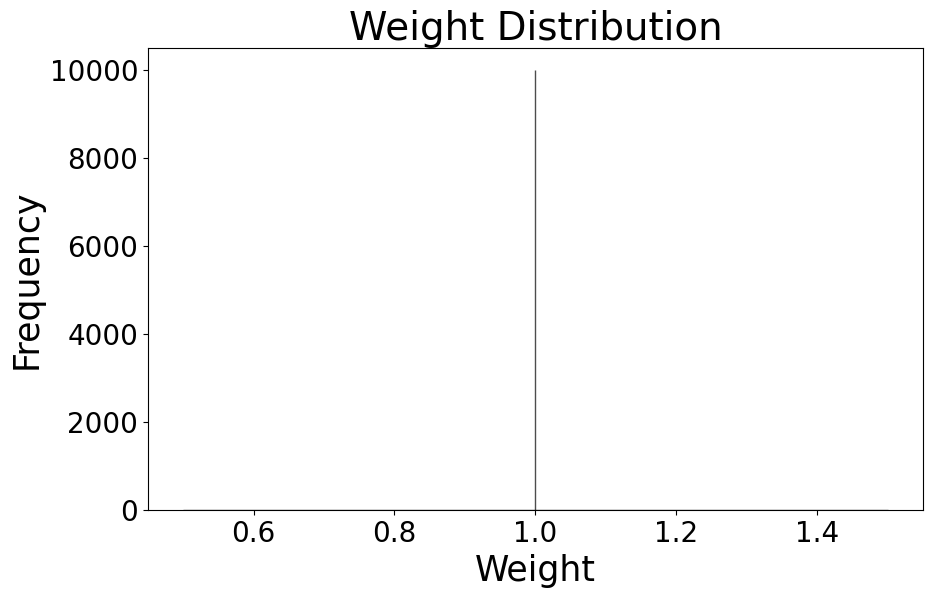

Number of clusters: 49
Number of modules: 42
threshold_percentile = 10%: threshold_distance = 25.355213034901496
Number of connected components: 1


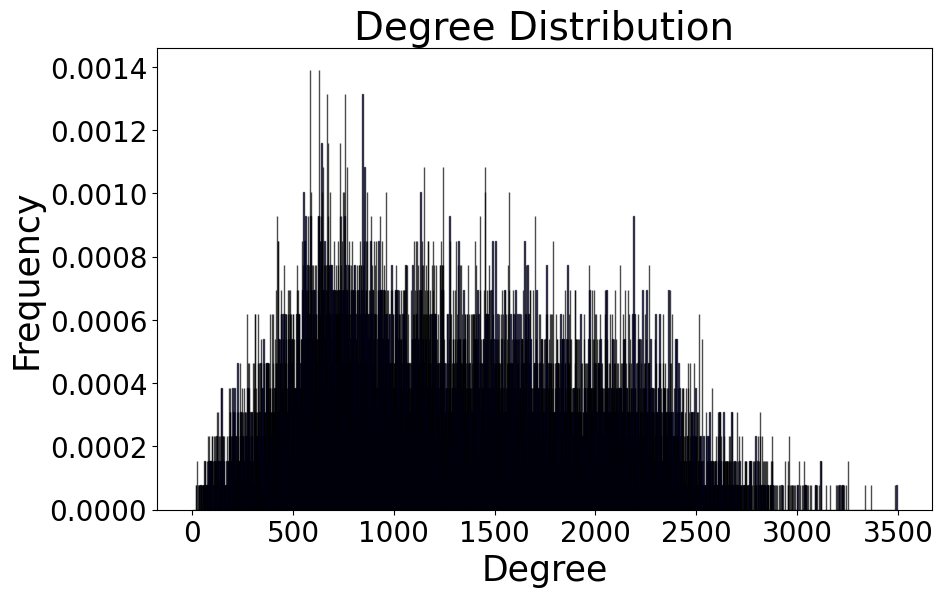

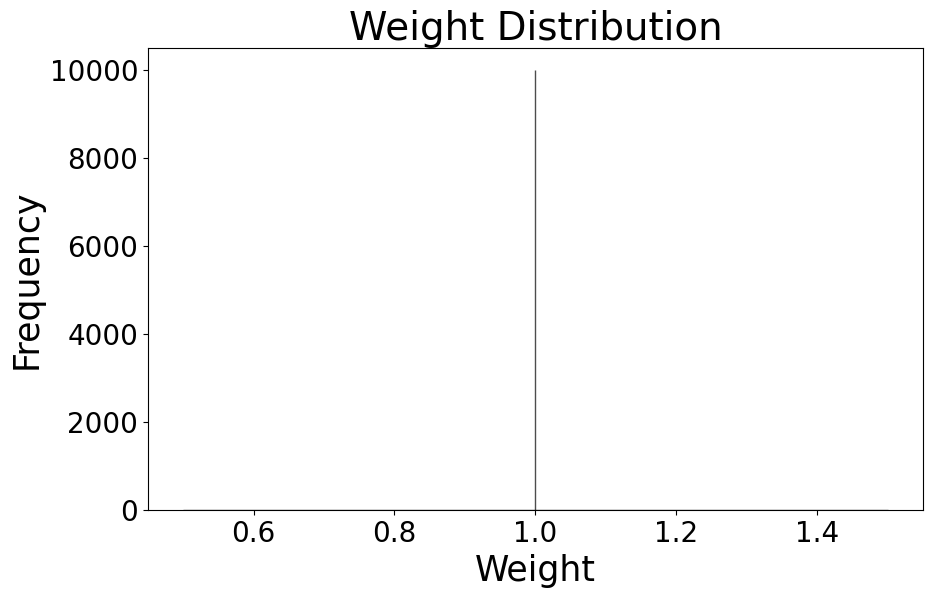

Number of clusters: 70
Number of modules: 58
threshold_percentile = 10%: threshold_distance = 25.355213034901496
Number of connected components: 1


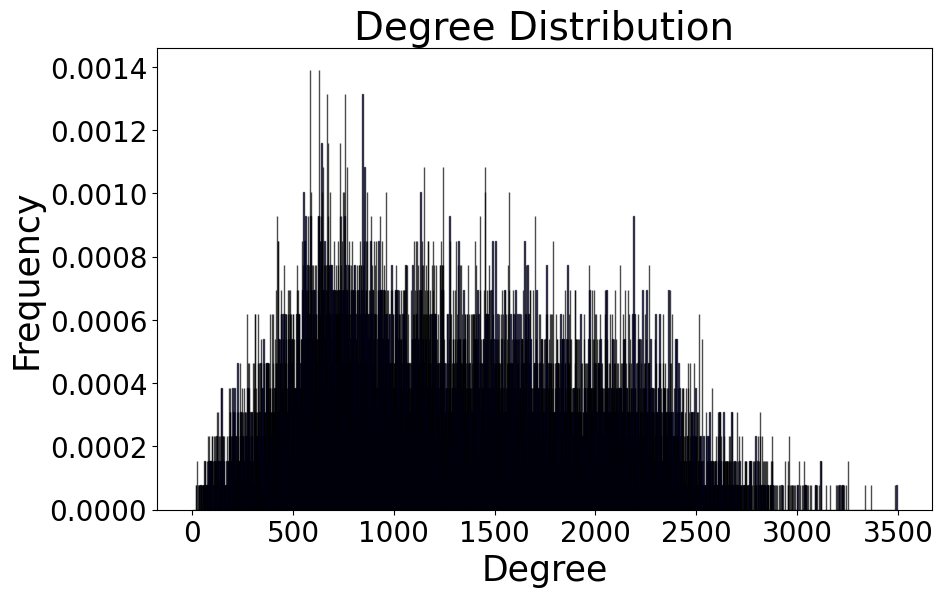

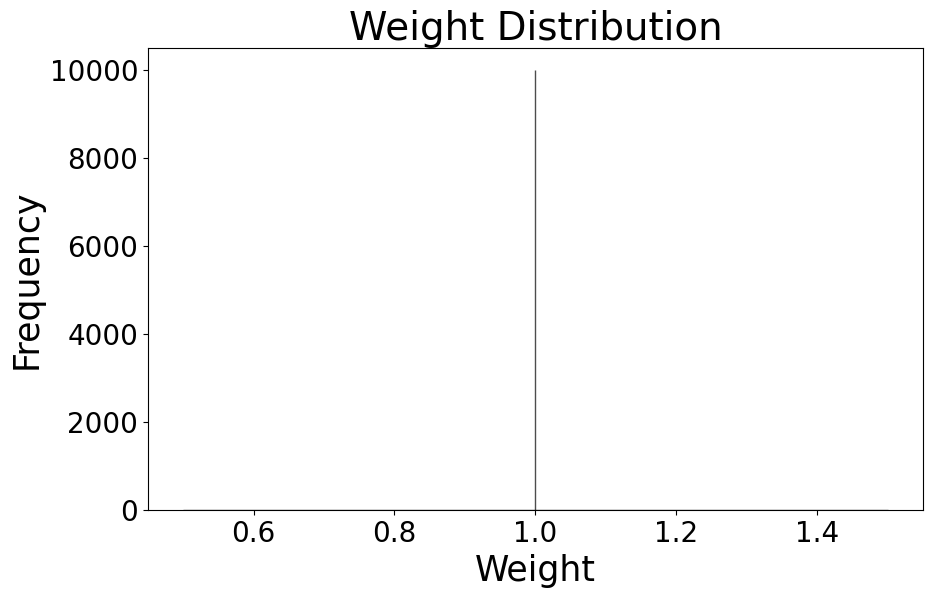

Number of clusters: 94
Number of modules: 76
threshold_percentile = 10%: threshold_distance = 25.355213034901496
Number of connected components: 1


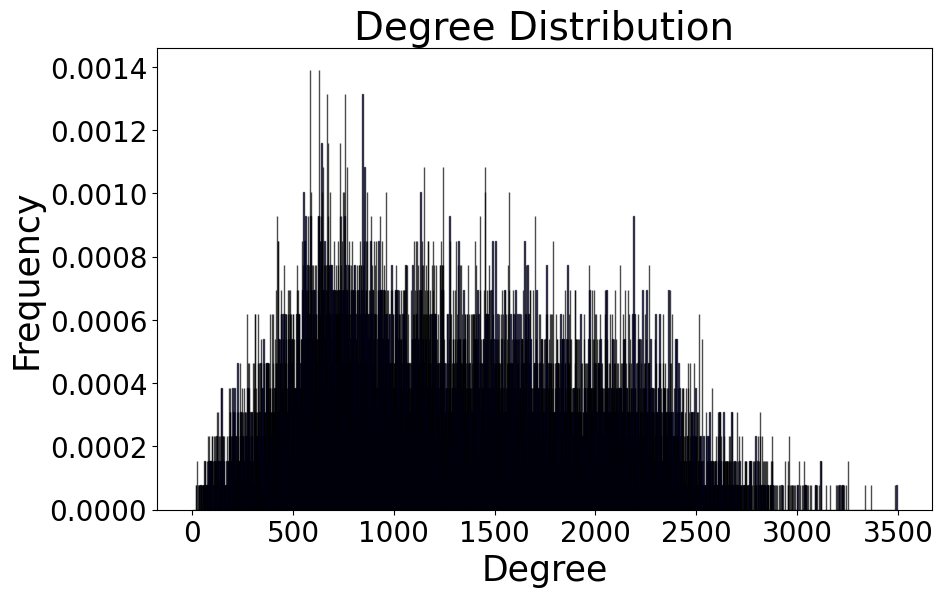

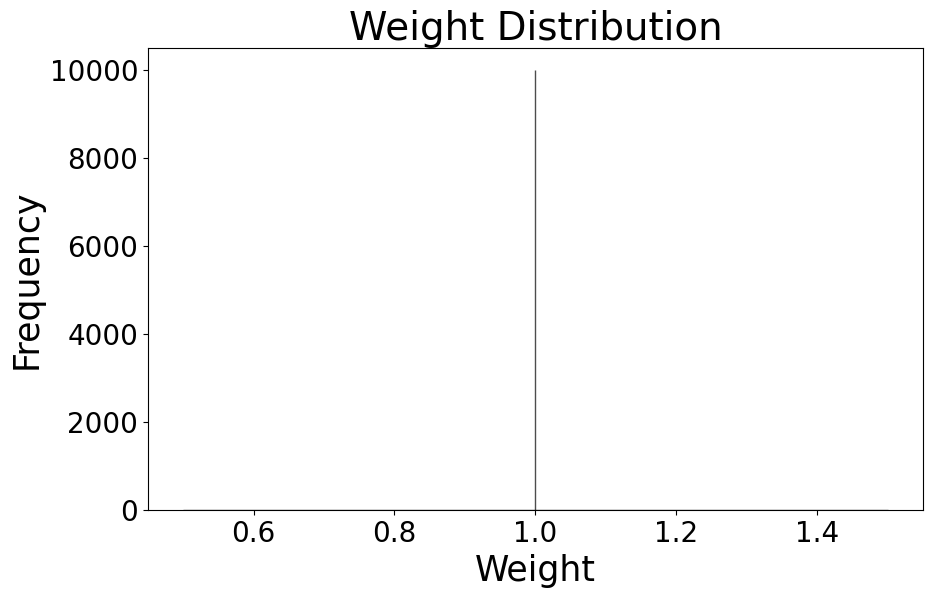

Number of clusters: 121
Number of modules: 95
threshold_percentile = 10%: threshold_distance = 25.355213034901496
Number of connected components: 1


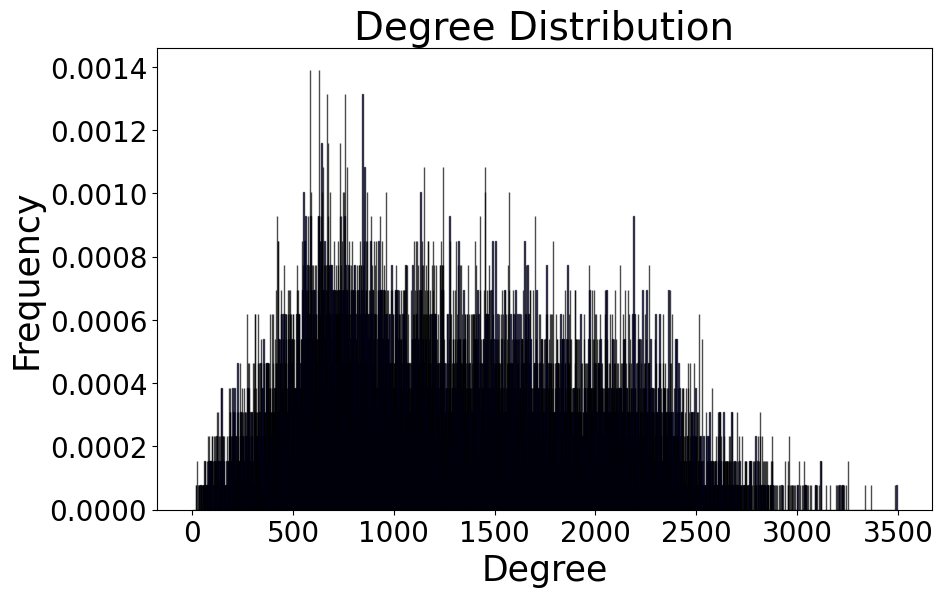

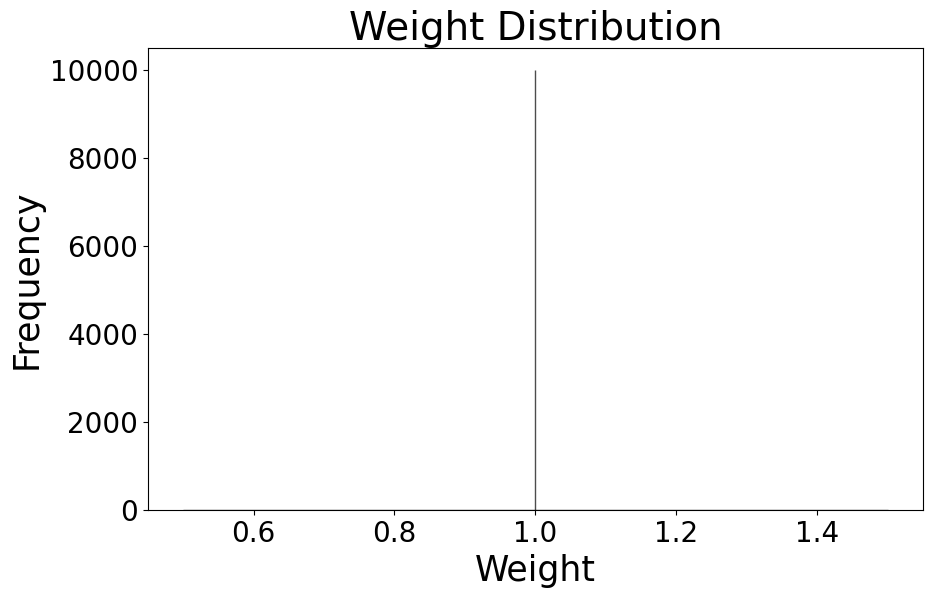

Number of clusters: 155
Number of modules: 127
threshold_percentile = 10%: threshold_distance = 25.355213034901496
Number of connected components: 1


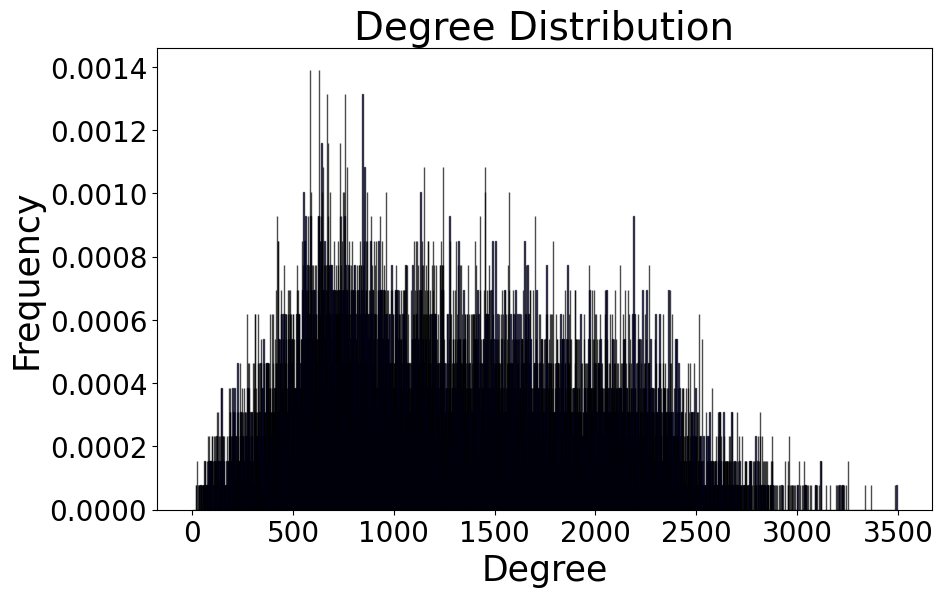

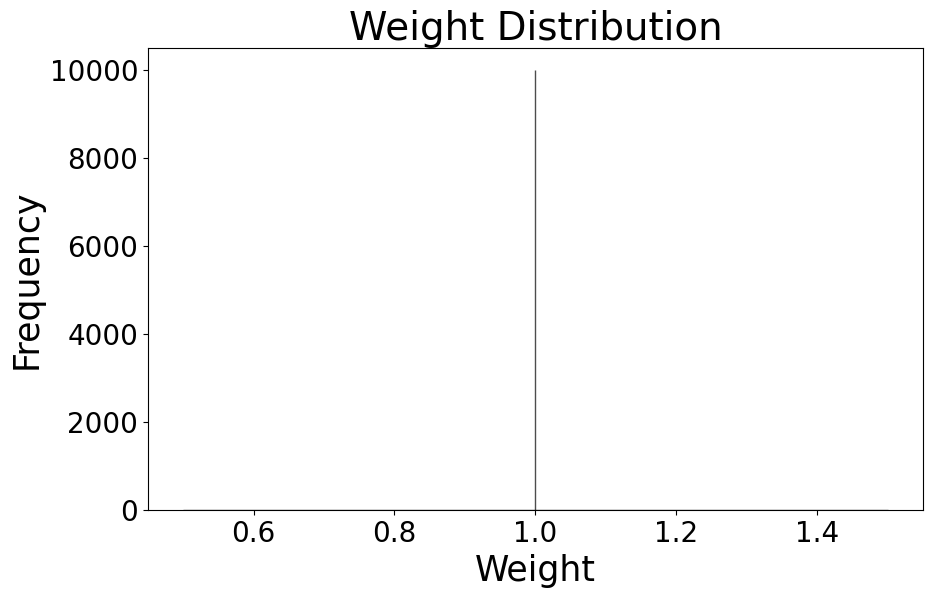

Number of clusters: 193
Number of modules: 160
threshold_percentile = 10%: threshold_distance = 25.355213034901496
Number of connected components: 1


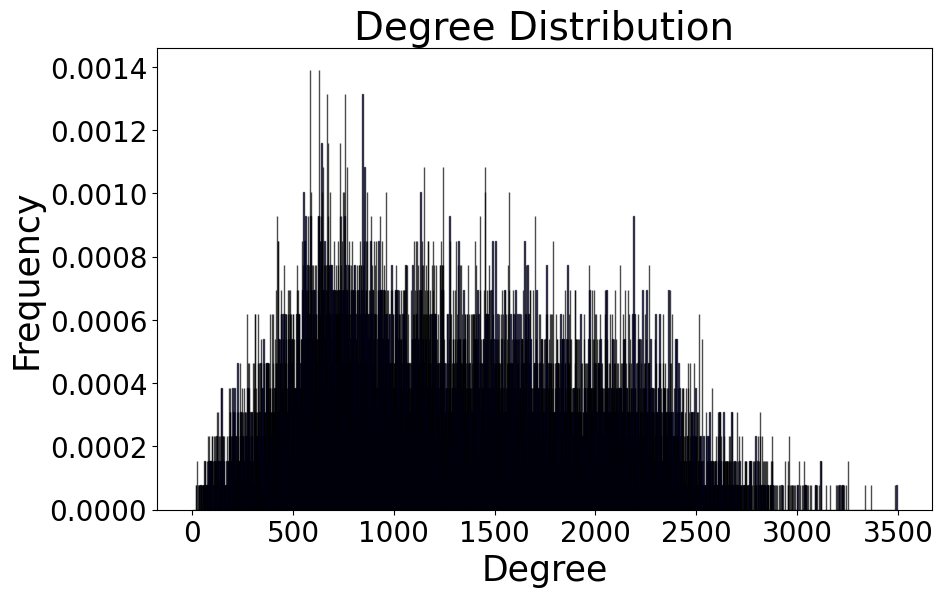

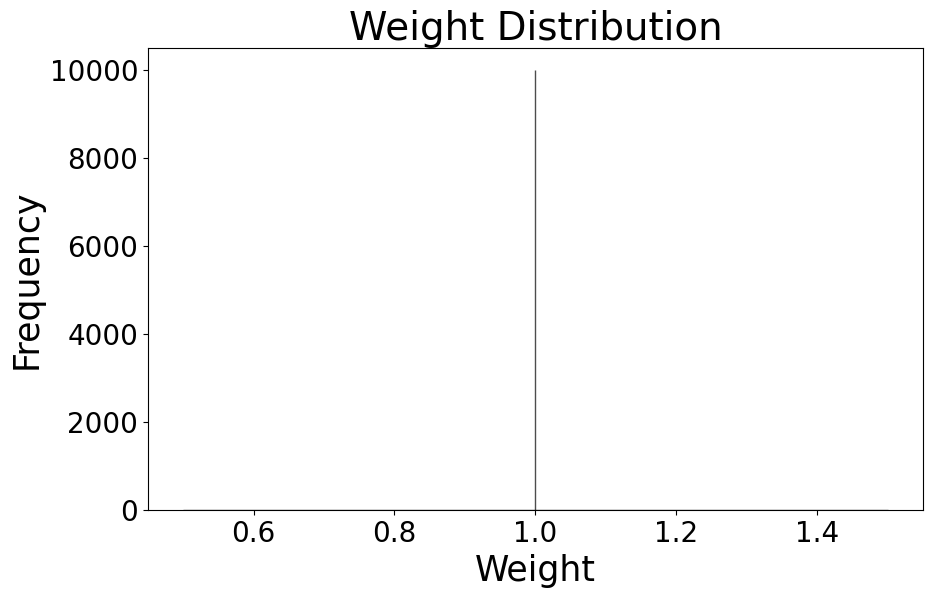

Number of clusters: 261
Number of modules: 215


In [10]:
for resolution_parameter in resolution_values:
    module_III = PCC_SWITCH_pcc_to_module_binary(pcc_coordinate=pcc_III, fig_path1=f"./figures/degree_distribution_III_{resolution_parameter}.svg", fig_path2=f"./figures/weight_distribution_III_{resolution_parameter}.svg", threshold_percentile=10, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_III, file_path=f"module_III_{resolution_parameter}.json")

threshold_percentile = 10%: threshold_distance = 22.789573425815906
Number of connected components: 1


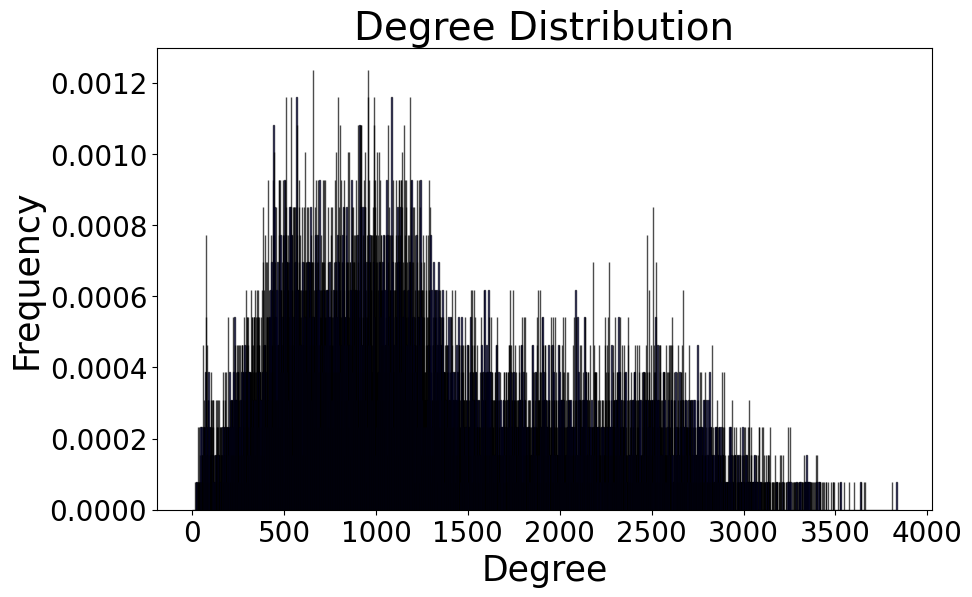

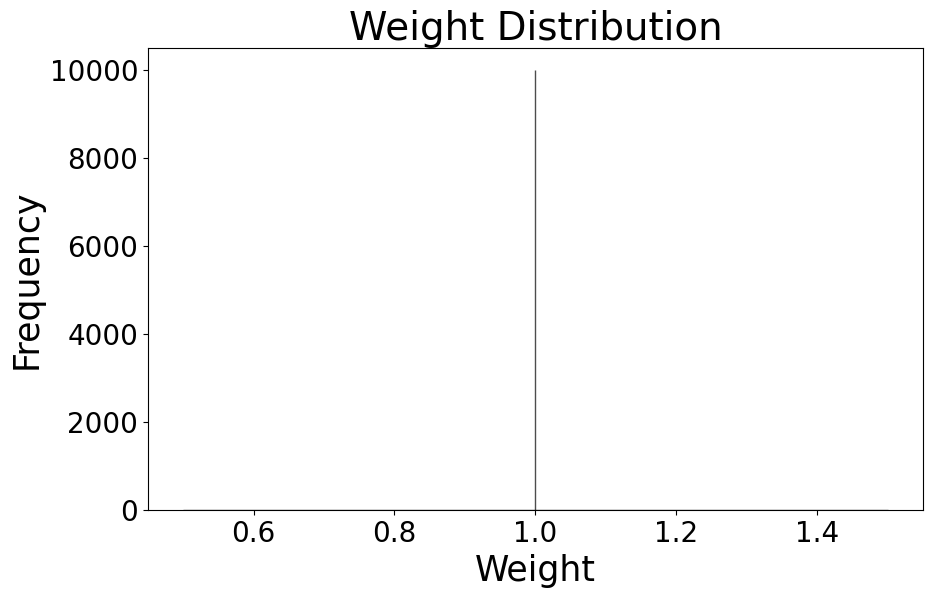

Number of clusters: 18
Number of modules: 15
threshold_percentile = 10%: threshold_distance = 22.789573425815906
Number of connected components: 1


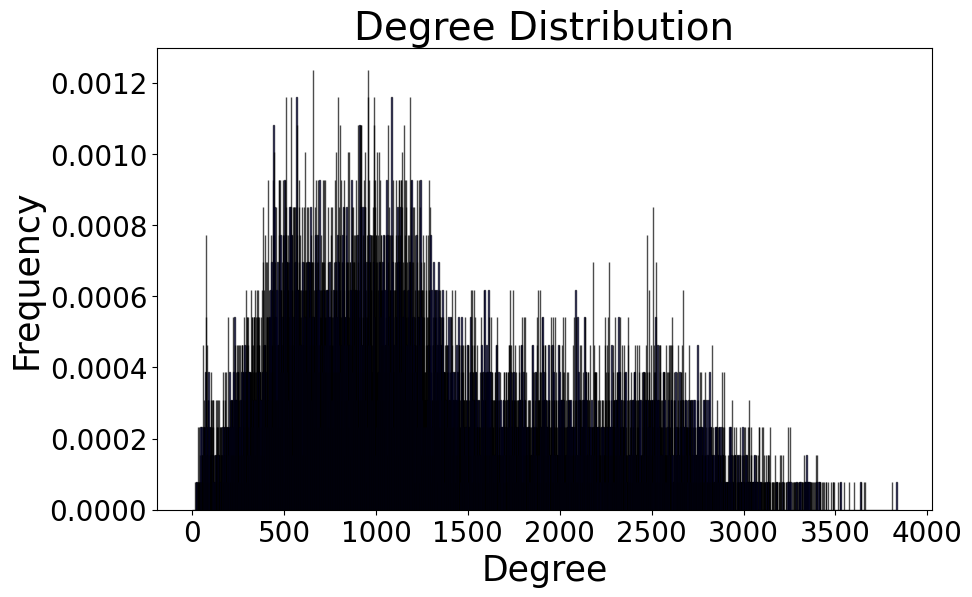

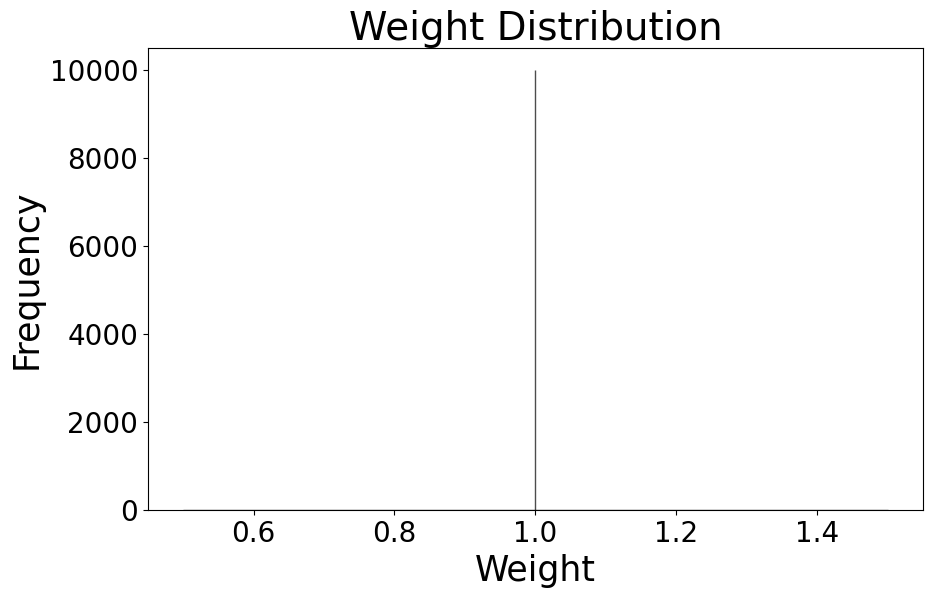

Number of clusters: 37
Number of modules: 30
threshold_percentile = 10%: threshold_distance = 22.789573425815906
Number of connected components: 1


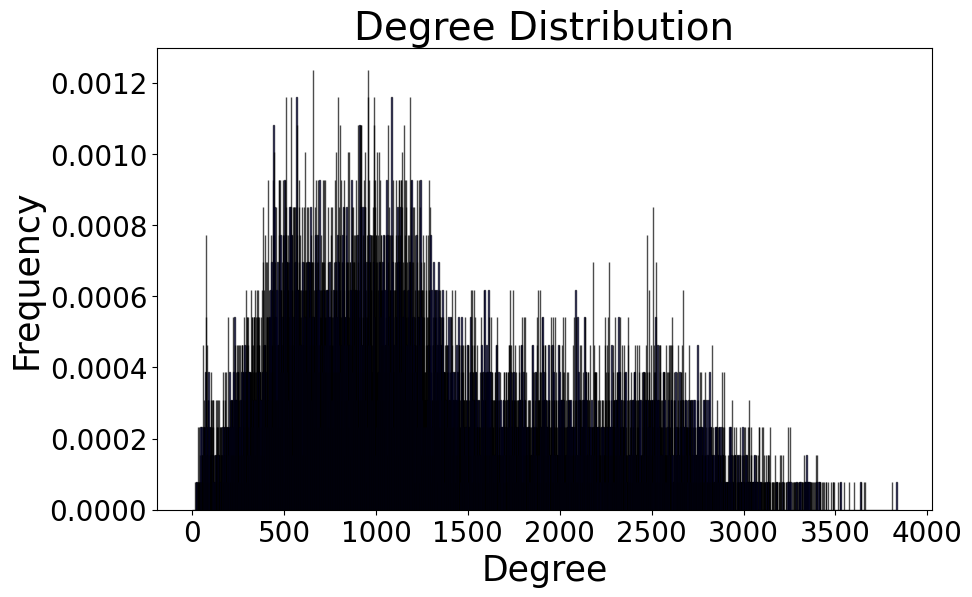

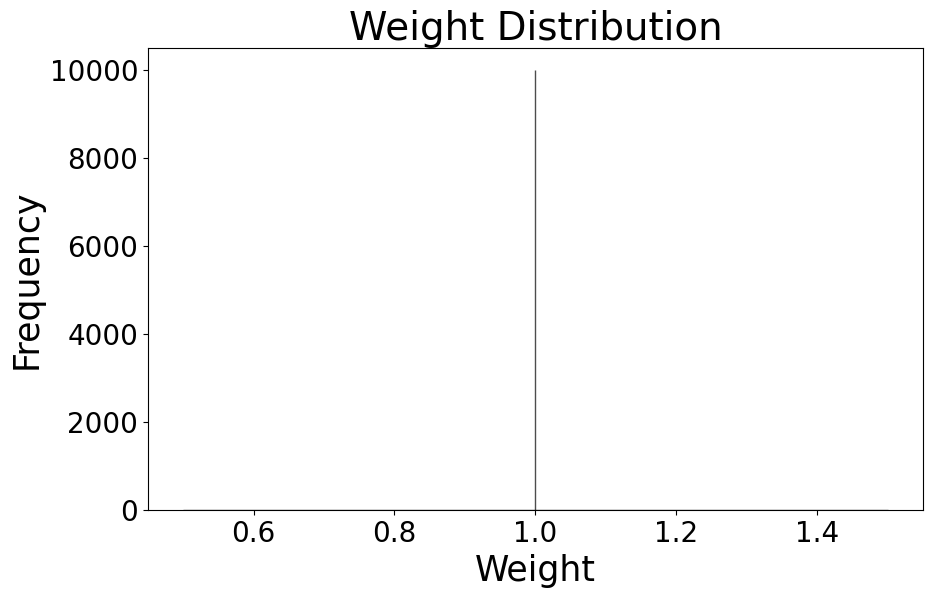

Number of clusters: 54
Number of modules: 44
threshold_percentile = 10%: threshold_distance = 22.789573425815906
Number of connected components: 1


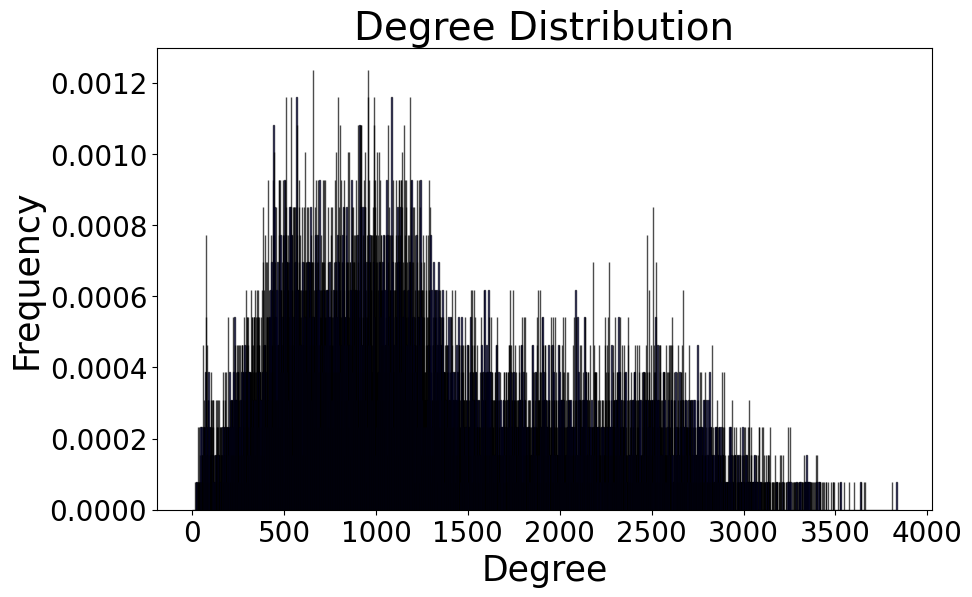

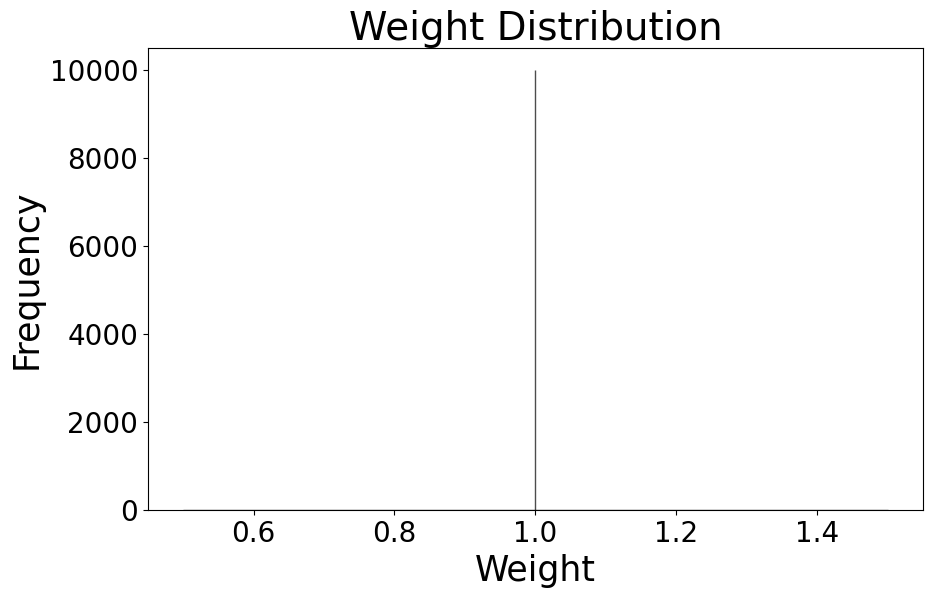

Number of clusters: 76
Number of modules: 61
threshold_percentile = 10%: threshold_distance = 22.789573425815906
Number of connected components: 1


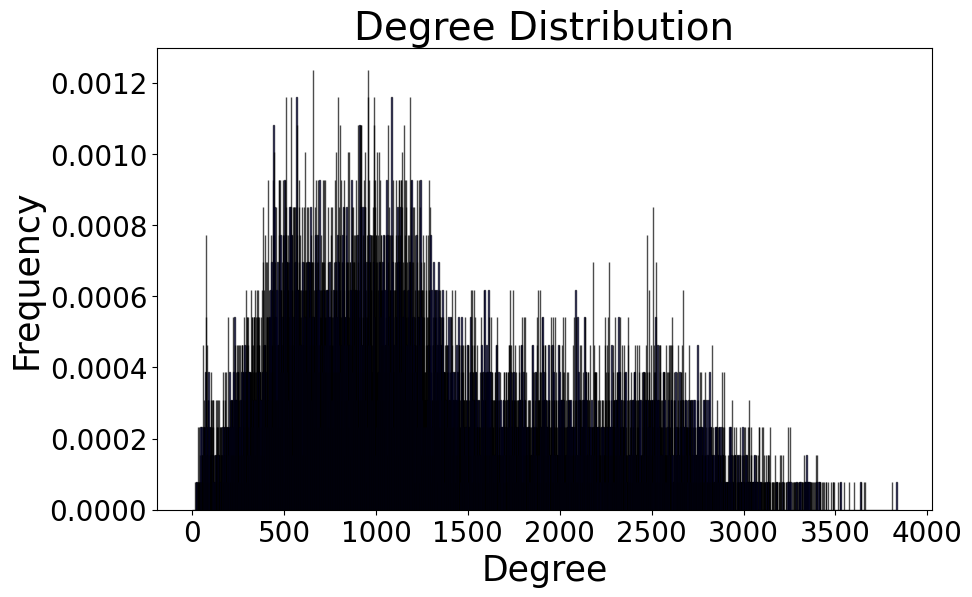

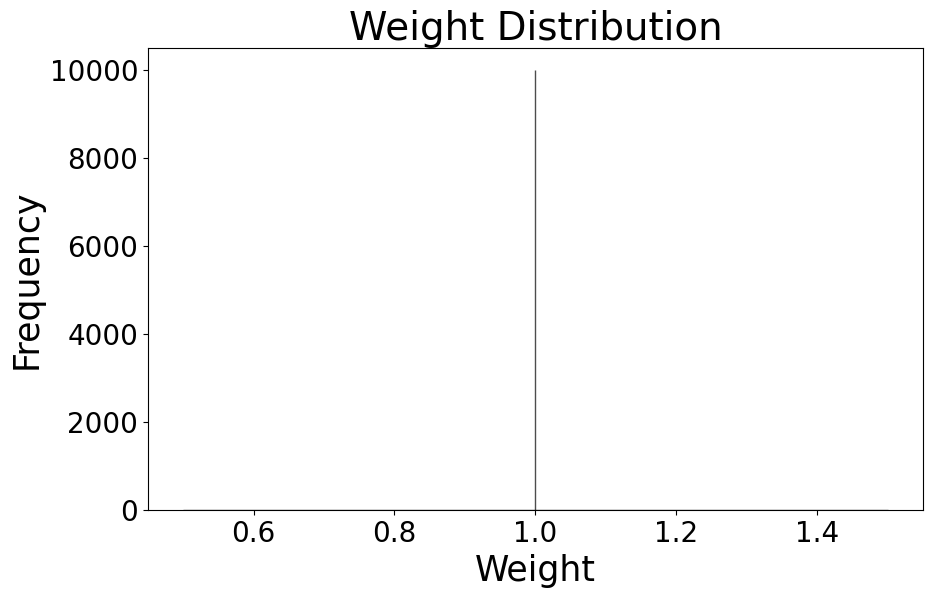

Number of clusters: 96
Number of modules: 83
threshold_percentile = 10%: threshold_distance = 22.789573425815906
Number of connected components: 1


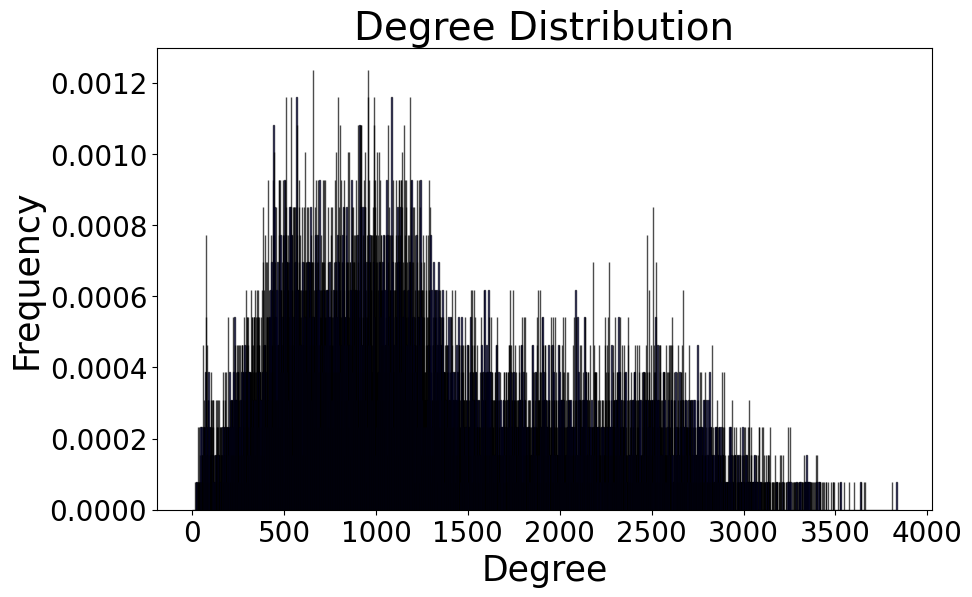

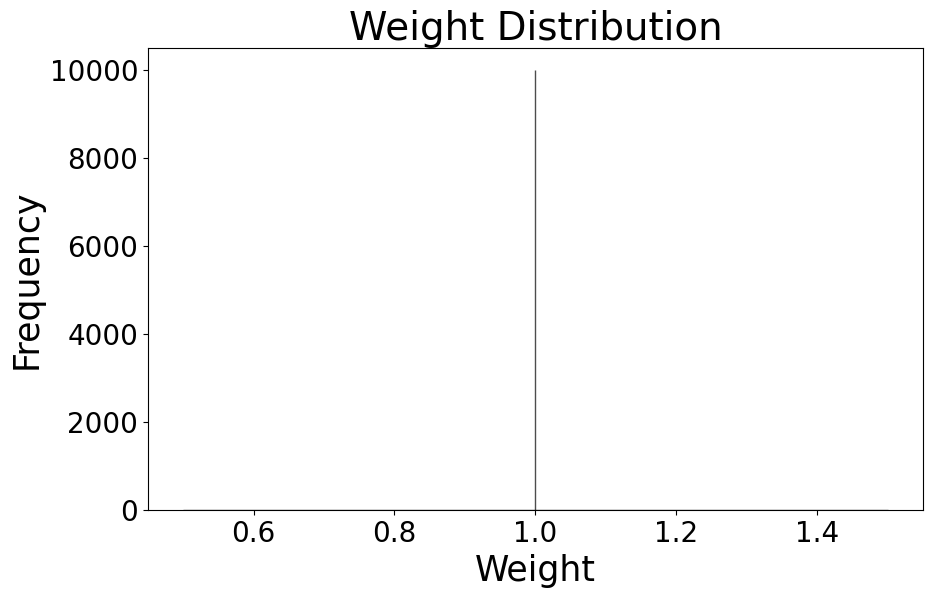

Number of clusters: 131
Number of modules: 105


IOStream.flush timed out


threshold_percentile = 10%: threshold_distance = 22.789573425815906
Number of connected components: 1


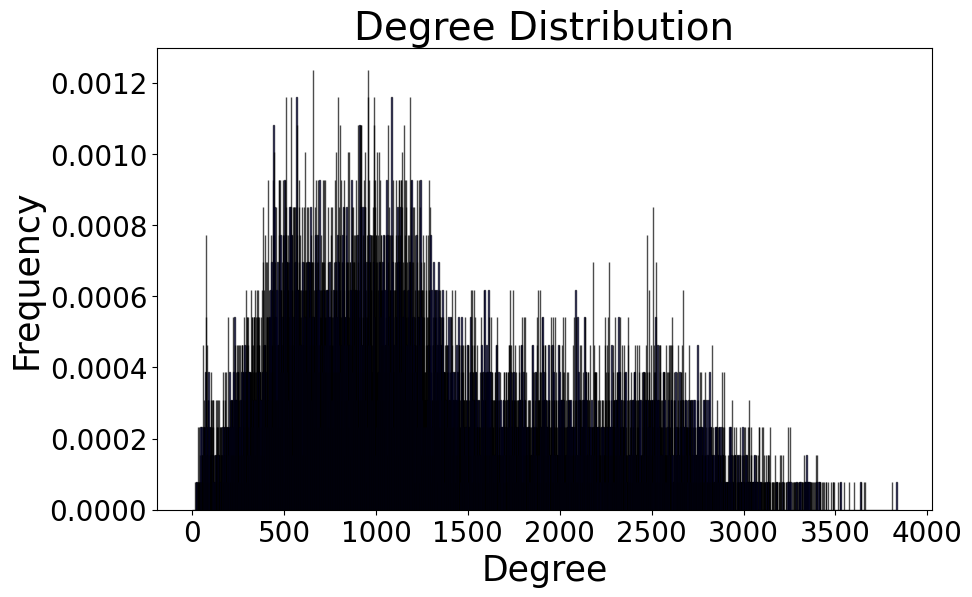

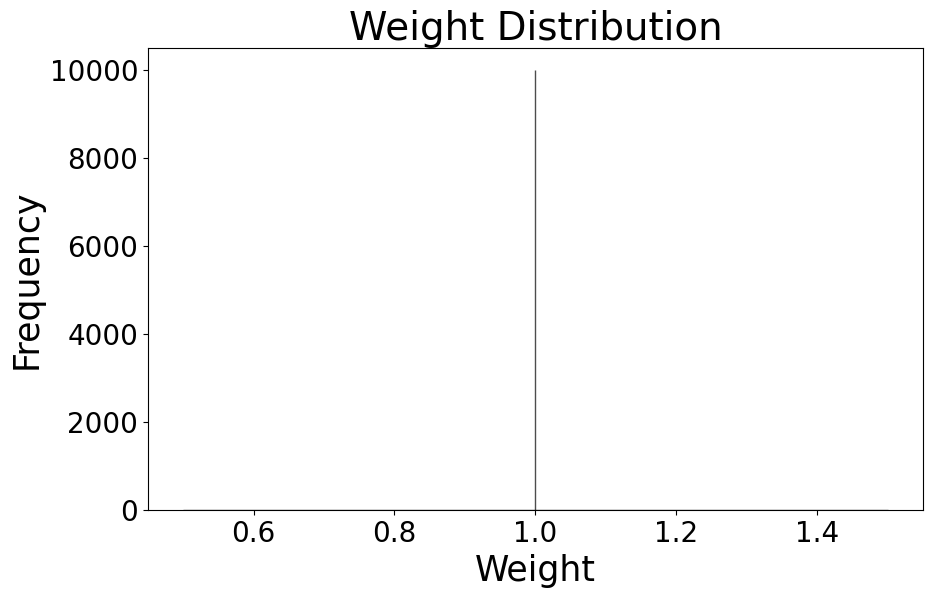

IOStream.flush timed out


Number of clusters: 167
Number of modules: 133


IOStream.flush timed out


threshold_percentile = 10%: threshold_distance = 22.789573425815906
Number of connected components: 1


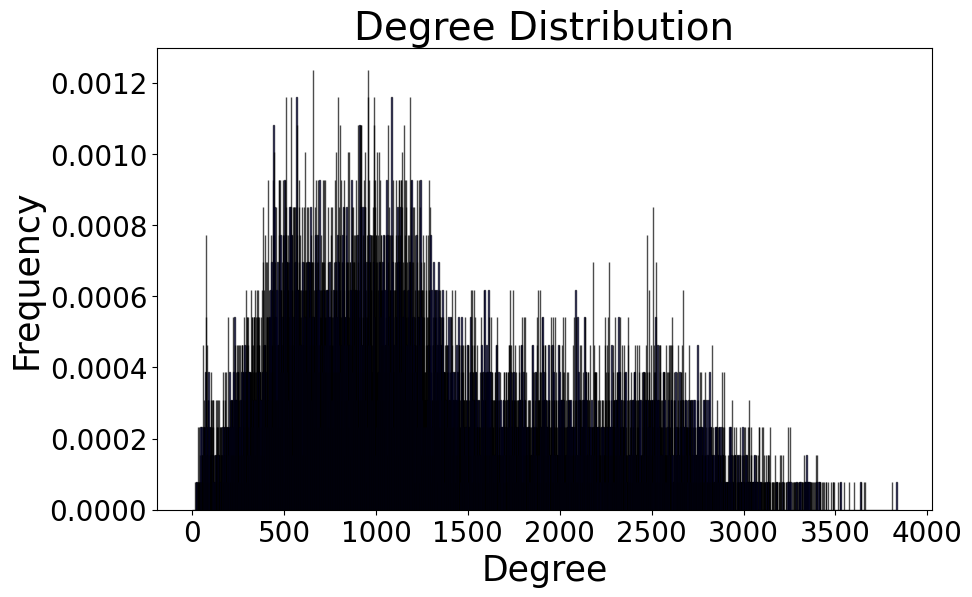

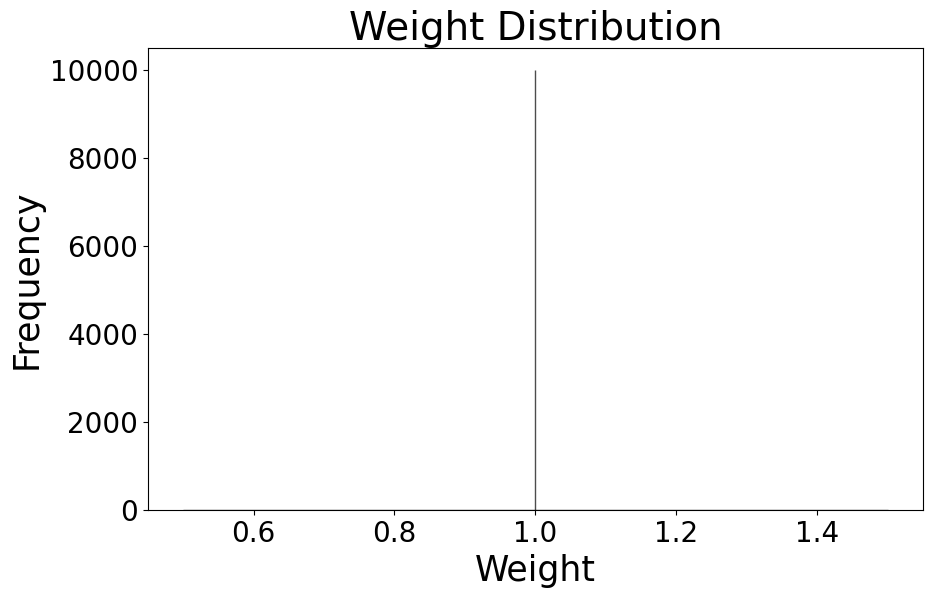

Number of clusters: 218
Number of modules: 174
threshold_percentile = 10%: threshold_distance = 22.789573425815906
Number of connected components: 1


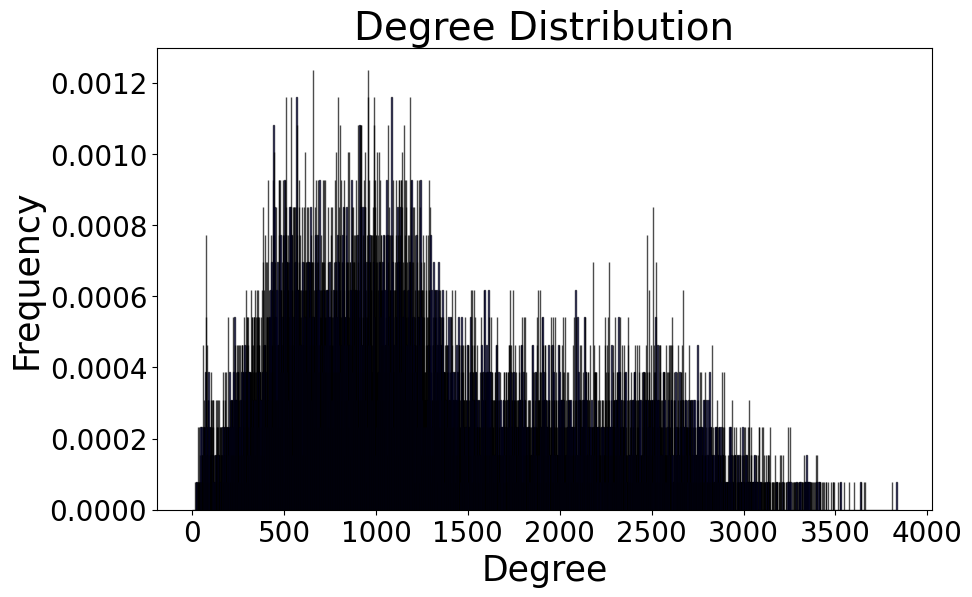

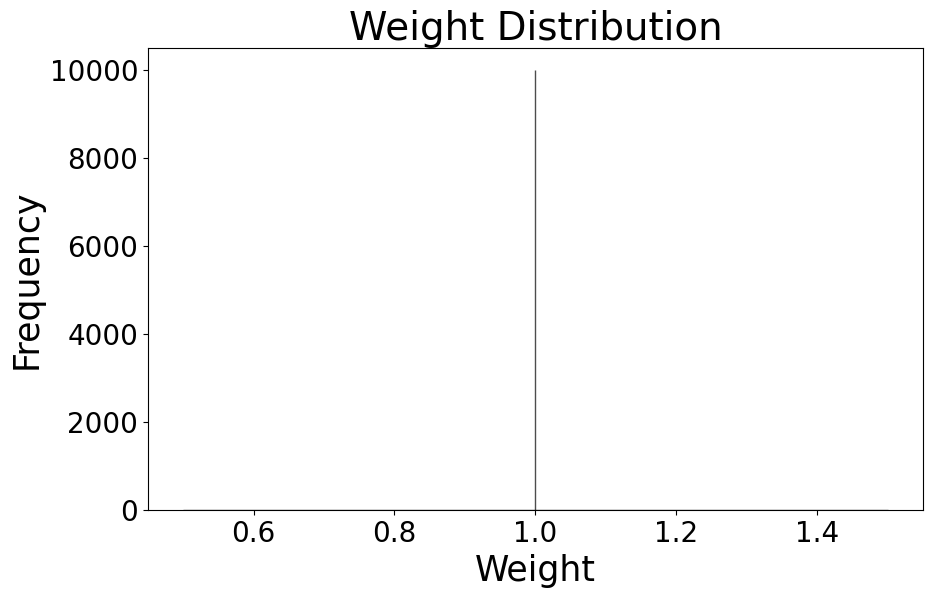

Number of clusters: 291
Number of modules: 242


In [11]:
for resolution_parameter in resolution_values:
    module_IV = PCC_SWITCH_pcc_to_module_binary(pcc_coordinate=pcc_IV, fig_path1=f"./figures/degree_distribution_IV_{resolution_parameter}.svg", fig_path2=f"./figures/weight_distribution_IV_{resolution_parameter}.svg", threshold_percentile=10, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_IV, file_path=f"module_IV_{resolution_parameter}.json")